# Imports

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Binarizer, OneHotEncoder, PowerTransformer, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

seed = 99

# Dataset: Hotel Reservation Cancellations

Binary classification project predicting hotel booking cancellations (~119k records).

**Target**: `reserva_cancelada` — 1 if cancelled, 0 if not.

**Key features**: 

`dias_antelacion` — lead_time: Number of days between the date the reservation is made and the guest's arrival date.

`fecha_llegada` — arrival_date: Start date of the reservation.

`noches_estancia` — stays_nights: Total number of nights included in the reservation.

`estado_reserva` — reservation_status: Final status of the reservation. Values: Canceled (the customer canceled the reservation), Check-Out (the customer completed the stay), No-Show (the customer neither arrived nor informed the hotel).

`fecha_estado_reserva` — reservation_status_date: Date when the reservation status was recorded.

`adultos` — adults: Number of adults included in the reservation.

`ninos` — children: Number of children included in the reservation.

`bebes` — babies: Number of babies included in the reservation.

`regimen_alimenticio` — meal_plan: Meal plan booked by the customer (BB: Bed & Breakfast, HB: Half Board, FB: Full Board, SC/Undefined: No meals included).

`tipo_habitacion_reservada` — reserved_room_type: Room type originally requested by the customer (encoded by letters: A, B, C, etc.).

`tipo_habitacion_asignada` — assigned_room_type: Room type assigned by the hotel at check-in.

`plazas_parking_requeridas` — required_parking_spaces: Number of parking spaces requested by the customer.

`peticiones_especiales_totales` — total_special_requests: Total number of special requests made by the customer (e.g., crib, extra bed, high floor).

`pais_origen` — country: Customer’s country of origin (three-letter international country code, e.g., PRT, ESP, FRA).

`segmento_mercado` — market_segment: Market segment to which the reservation belongs (e.g., Direct, Groups, Corporate Travel Agencies, etc.).

`canal_distribucion` — distribution_channel: Booking channel through which the reservation was made (e.g., TA/TO: Travel Agents/Tour Operators, Direct, GDS, etc.).

`cliente_repetido` — is_repeated_guest: Binary variable (0 or 1) indicating whether the customer has stayed at this hotel before.

`cancelaciones_previas` — previous_cancellations: Number of reservations previously canceled by the customer before the current booking.

`reservas_previas_no_canceladas` — previous_bookings_not_canceled: Number of previous reservations successfully completed by the customer.

`tipo_deposito` — deposit_type: Indicates whether the customer made a deposit to secure the reservation (No Deposit, Non Refundable, Refundable).

`cambios_reserva` — booking_changes: Number of modifications made to the reservation between booking creation and arrival date.

`dias_lista_espera` — days_in_waiting_list: Number of days the reservation remained on the waiting list before being confirmed.

`tipo_cliente` — customer_type: Type of customer/reservation (Transient: individual traveler, Group: group reservation, Contract: recurring corporate contract, Transient-Party: individual associated with a group).

`precio_medio_diario` — average_daily_rate: Average Daily Rate (ADR) paid by the customer per room per night.


Data source: [reservas_hotel.csv](https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/reservas_hotel.csv)

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/reservas_hotel.csv")
df.head()

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,fecha_estado_reserva,fecha_llegada,noches_estancia
0,0,342,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-06,0
1,0,737,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-06,0
2,0,7,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-06,1
3,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-06,1
4,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-06,2


In [3]:
df.shape

(119390, 25)

In [4]:
# Create a working copy of the dataset to preserve the original data.

df1 = df.copy()

In [5]:
# Rename features: the original dataset was provided in Spanish
rename_dict = {
    'reserva_cancelada': 'is_canceled',
    'dias_antelacion': 'lead_time',
    'adultos': 'adults',
    'ninos': 'children',
    'bebes': 'babies',
    'regimen_alimenticio': 'meal_plan',
    'pais_origen': 'country',
    'segmento_mercado': 'market_segment',
    'canal_distribucion': 'distribution_channel',
    'cliente_repetido': 'is_repeated_guest',
    'cancelaciones_previas': 'previous_cancellations',
    'reservas_previas_no_canceladas': 'previous_bookings_not_canceled',
    'tipo_habitacion_reservada': 'reserved_room_type',
    'tipo_habitacion_asignada': 'assigned_room_type',
    'cambios_reserva': 'booking_changes',
    'tipo_deposito': 'deposit_type',
    'dias_lista_espera': 'days_in_waiting_list',
    'tipo_cliente': 'customer_type',
    'precio_medio_diario': 'average_daily_rate',
    'plazas_parking_requeridas': 'required_parking_spaces',
    'peticiones_especiales_totales': 'total_special_requests',
    'noches_estancia': 'stays_nights',
    'estado_reserva' : 'reservation_status',
    'fecha_estado_reserva' : 'reservation_status_date',
    'fecha_llegada' : 'arrival_date'
}

df1.rename(columns=rename_dict, inplace=True)

# 1. EDA & Feature Engineering

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     119390 non-null  int64  
 1   lead_time                       119390 non-null  int64  
 2   adults                          119390 non-null  int64  
 3   children                        119386 non-null  float64
 4   babies                          119390 non-null  int64  
 5   meal_plan                       119390 non-null  str    
 6   country                         118902 non-null  str    
 7   market_segment                  119390 non-null  str    
 8   distribution_channel            119390 non-null  str    
 9   is_repeated_guest               119390 non-null  int64  
 10  previous_cancellations          119390 non-null  int64  
 11  previous_bookings_not_canceled  119390 non-null  int64  
 12  reserved_room_type         

In [7]:
# Remove features containing information that would not be available at the time of prediction. 
# These variables are directly linked to the final outcome of the reservation and would lead to data leakage.

df1.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

In [8]:
# Check for duplicated records
df1.duplicated().sum()

# The dataset contains 32,405 duplicated rows. However, there is no unique booking identifier available, 
# meaning that identical records may correspond to different reservations. Therefore, duplicated rows are
# retained to avoid the potential loss of valid information

np.int64(32405)

In [9]:
# 'arrival_date' is the only remaining date variable and is currently stored as a string
# Convert it to pandas datetime format
df1['arrival_date'] = pd.to_datetime(df1['arrival_date'])

# Extract temporal features from the arrival date
df1['arrival_year'] = df1['arrival_date'].dt.year
df1['arrival_quarter'] = df1['arrival_date'].dt.quarter
df1['arrival_month'] = df1['arrival_date'].dt.month
df1['arrival_weekday'] = df1['arrival_date'].dt.dayofweek
df1['arrival_weekend'] = df1['arrival_weekday'].isin([5, 6])

# Inspect the newly created features
df1[['arrival_year',
     'arrival_quarter',
     'arrival_month',
     'arrival_weekday',
     'arrival_weekend']]

,arrival_year,arrival_quarter,arrival_month,arrival_weekday,arrival_weekend
0,2015,3,7,0,False
1,2015,3,7,0,False
2,2015,3,7,0,False
3,2015,3,7,0,False
4,2015,3,7,0,False
...,...,...,...,...,...
119385,2017,3,8,0,False
119386,2017,3,8,0,False
119387,2017,3,8,0,False
119388,2017,3,8,0,False


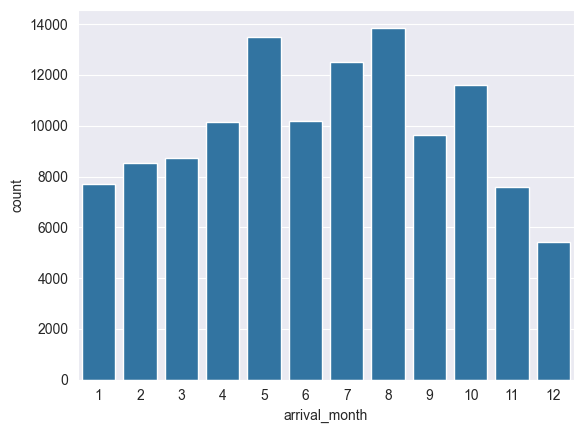

In [10]:
# Inspect the values generated from the arrival date
df1['arrival_date'].unique()
df1['arrival_year'].unique()
df1['arrival_quarter'].unique()
df1['arrival_month'].unique()
df1['arrival_weekday'].nunique() 

# All arrival dates correspond to Mondays (weekday = 0). Therefore, 'arrival_weekday' and 'arrival_weekend'
# contain no variability and do not provide useful information for the models.
df1.drop(columns=['arrival_weekday', 'arrival_weekend'], inplace=True)

# Explore the distribution of arrivals by month

sns.countplot(data=df1, x='arrival_month')
plt.show()

# A high-season indicator was initially considered. However, the monthly distribution does not show a clear
# separation between high and low seasons, and the original month feature retains more detailed seasonal
# information. Therefore, only 'arrival_month' is retained.

# Remove the original date column
df1.drop(columns=['arrival_date'], inplace=True)

### New Features Created

 - **arrival_month**: Month of arrival, used to capture seasonal booking patterns.
 - **arrival_quarter**: Quarter of arrival, providing a more aggregated representation of seasonality.
 - **arrival_year**: Year of arrival, allowing the detection of potential changes in booking behavior over time.

Additional features based on the day of the week were initially considered. However, all arrival dates in the dataset
correspond to Mondays, resulting in constant variables with no predictive value. These features were therefore removed. 

A high-season feature was considered based on the assumption that summer months could concentrate a larger number of bookings.

# 2. Data Split

The dataset is divided into training (80%) and test (20%) sets using a stratified sampling strategy. Since approximately 37% of reservations are canceled, stratification ensures that the class distribution remains consistent across both subsets, providing a more reliable evaluation of model performance. 

In [11]:
X = df1.drop(columns='is_canceled')
y = df1['is_canceled']

y.value_counts()
y.mean() # Approximately 37% of the reservations are canceled, so this proportion will be maintained in the data split using stratification.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

# 3. EDA & Feature Engineering

### Missing Data Handling

In [12]:
# Check for missing values in the training set
X_train.isna().sum()

# There is 1 missing value in the 'childen' variable and 370 in the 'country' variable within the training set. 
# Since they represent a very small percentage of the total data, they could be dropped. However, their correlation 
# with the target variable will be analyzed first. If they show a low correlation, it is considered better to impute 
# them (as that missingness likely doesn't provide significant information to the model) and keep the records, 
# thereby avoiding data loss.

lead_time                           0
adults                              0
children                            1
babies                              0
meal_plan                           0
country                           370
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
customer_type                       0
average_daily_rate                  0
required_parking_spaces             0
total_special_requests              0
stays_nights                        0
arrival_year                        0
arrival_quarter                     0
arrival_month                       0
dtype: int64

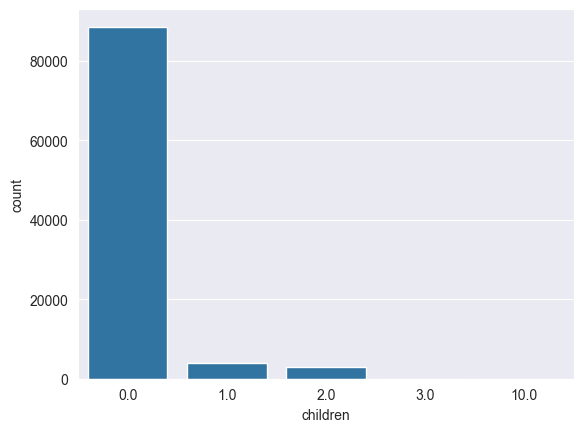

In [13]:
# Feature: 'children'

# Check correlation with the target variable
X_train['children'].corr(y_train) # low correlation (0.005)

# Visualize the distribution
sns.countplot(data=X_train, x='children')
plt.show()

# Impute missing values with the median (0) due to its highly skewed distribution
imputer_children = SimpleImputer(strategy='median')
X_train[['children']] = imputer_children.fit_transform(X_train[['children']])
X_test[['children']] = imputer_children.transform(X_test[['children']])

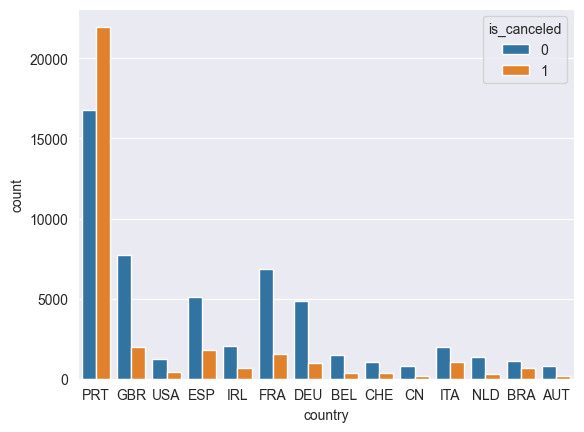

In [14]:
# Feature 'country'

# Inspect value counts
X_train['country'].value_counts()

# To handle high cardinality, filter and visualize only the most frequent countries (>= 1000 bookings)
top_countries = X_train['country'].value_counts()
top_countries = top_countries[top_countries >= 1000].index
df_countries = X_train[X_train['country'].isin(top_countries)]

# Plot country distribution colored by cancellation status
sns.countplot(data=df_countries, x='country', hue=y_train)
plt.show()

# There is high variability across countries; for instance, Portugal cancels more than half of its reservations, 
# while others show much lower cancellation rates. Since there might be a correlation with the target variable, 
# missing values will be imputed as "unknown".

# Impute missing values using a constant strategy to create an 'Unknown' category
imputer_country = SimpleImputer(strategy='constant', fill_value='Unknown')
X_train[['country']] = imputer_country.fit_transform(X_train[['country']])
X_test[['country']] = imputer_country.transform(X_test[['country']])

In [15]:
# Confirm that no missing values remain and the 'Unknown' category was properly assigned
print("Missing values in Train:", X_train.isna().sum().sum())
print("Missing values in Test:", X_test.isna().sum().sum())
X_train['country'].value_counts().head(25)

Missing values in Train: 0
Missing values in Test: 0


country
PRT        38734
GBR         9718
FRA         8362
ESP         6879
DEU         5847
ITA         3020
IRL         2701
BEL         1875
BRA         1787
NLD         1698
USA         1656
CHE         1398
CN          1009
AUT         1003
SWE          828
CHN          822
POL          760
ISR          525
RUS          507
NOR          480
ROU          416
Unknown      370
FIN          365
AUS          340
DNK          338
Name: count, dtype: int64

**Explanation of the Imputations Performed**

Although the 'children' variable had only 5 missing rows across the entire dataset (representing a negligible percentage 
of total records), its extremely low correlation with the target variable suggests it won't be critical for the model. 
Therefore, imputing with the median is preferable to dropping the entire row and losing data. Furthermore, given the 
sparse number of missing values, any reasonable imputation method will have virtually zero impact on the model. 
The median or mode is chosen due to its skewed distribution centered at 0, resulting in an imputed value of 0.

The 'country' variable has more missing records, but it still accounts for a small percentage of the total dataset. 
While these could also be dropped, the visualization reveals high variability across countries, indicating it could 
significantly influence the target variable. In this case, imputation using summary statistics is avoided to prevent 
introducing false assumptions. The KNN method is discarded because the variable is categorical; encoding, imputing, 
and decoding would be inefficient just to impute 488 values in a 119,390-record dataset. Additionally, since 32,405 
duplicate records were previously identified, KNN would likely yield the same results as mode imputation but with a 
much higher computational cost. Instead, constant imputation with the value 'Unknown' is applied, creating a new category 
to represent the missing data. This approach may also help uncover patterns if this missingness correlates with other 
variables

### Feature Classification

In [16]:
cat_cols = ['meal_plan', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest',
            'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

ord_cols = ['arrival_year', 'arrival_quarter', 'arrival_month']

num_cols = ['lead_time', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled',
            'booking_changes', 'days_in_waiting_list', 'average_daily_rate', 'required_parking_spaces', 'total_special_requests',
            'stays_nights']

### Numerical Features Analysis

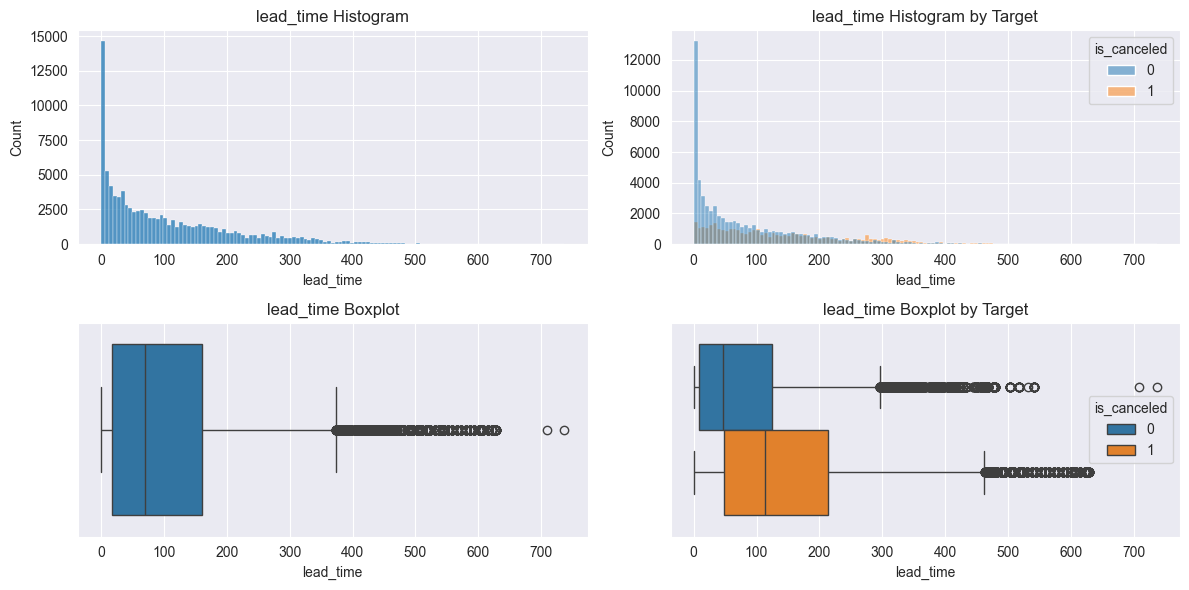

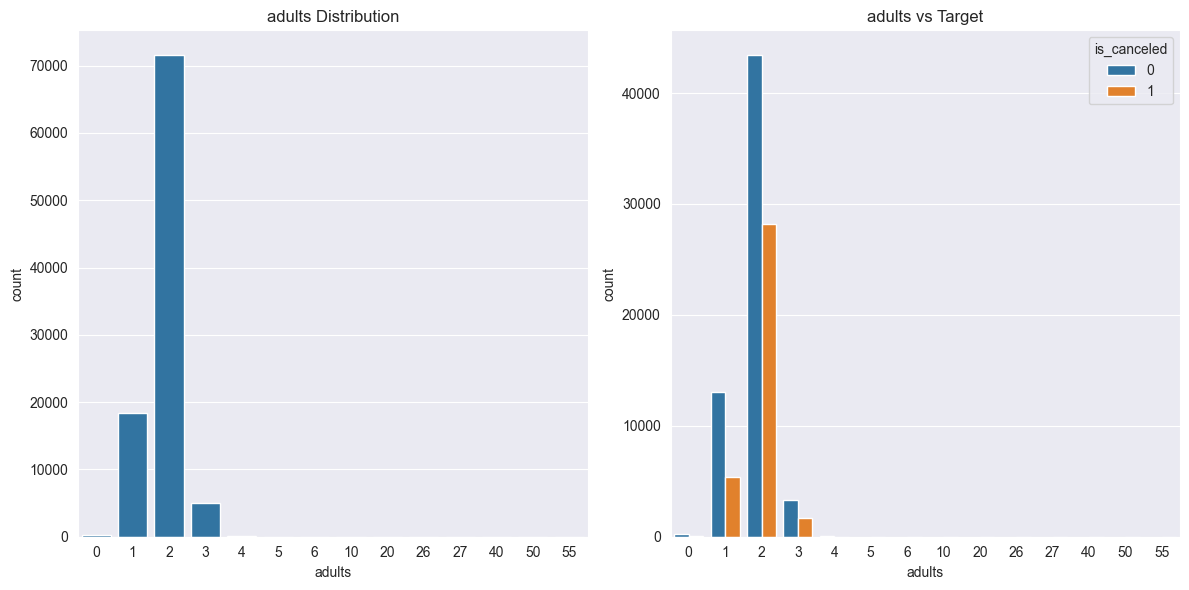

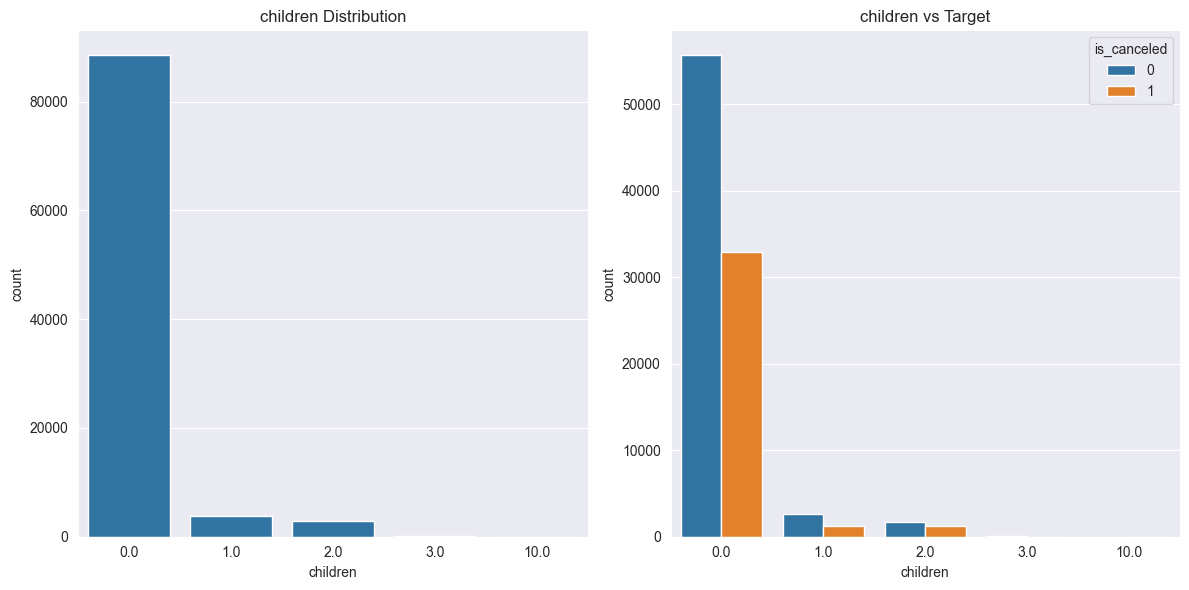

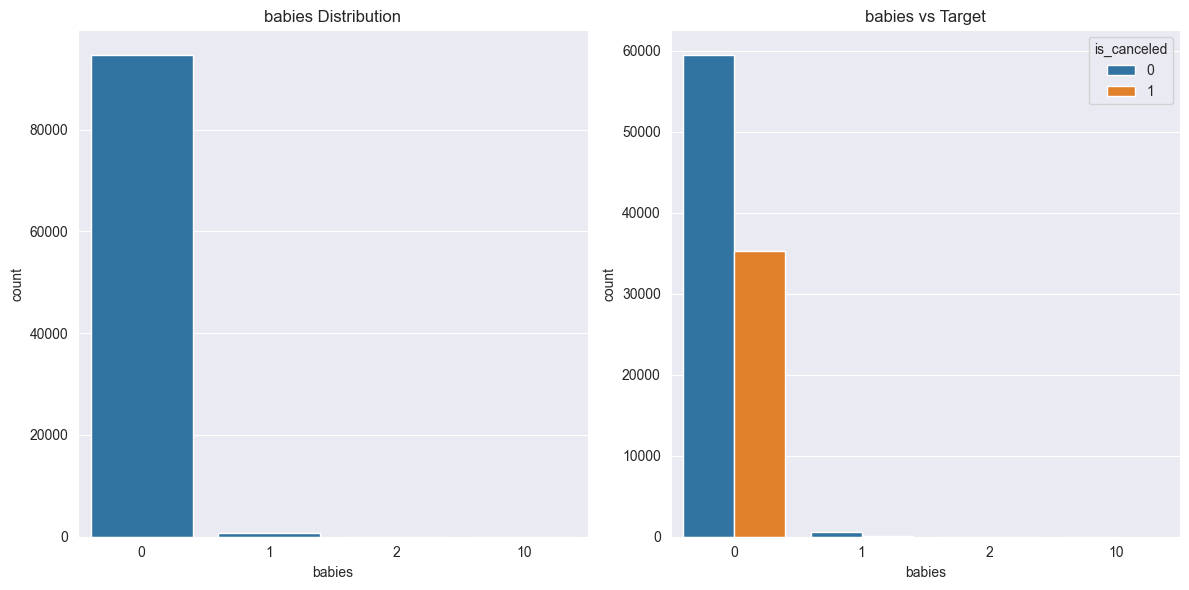

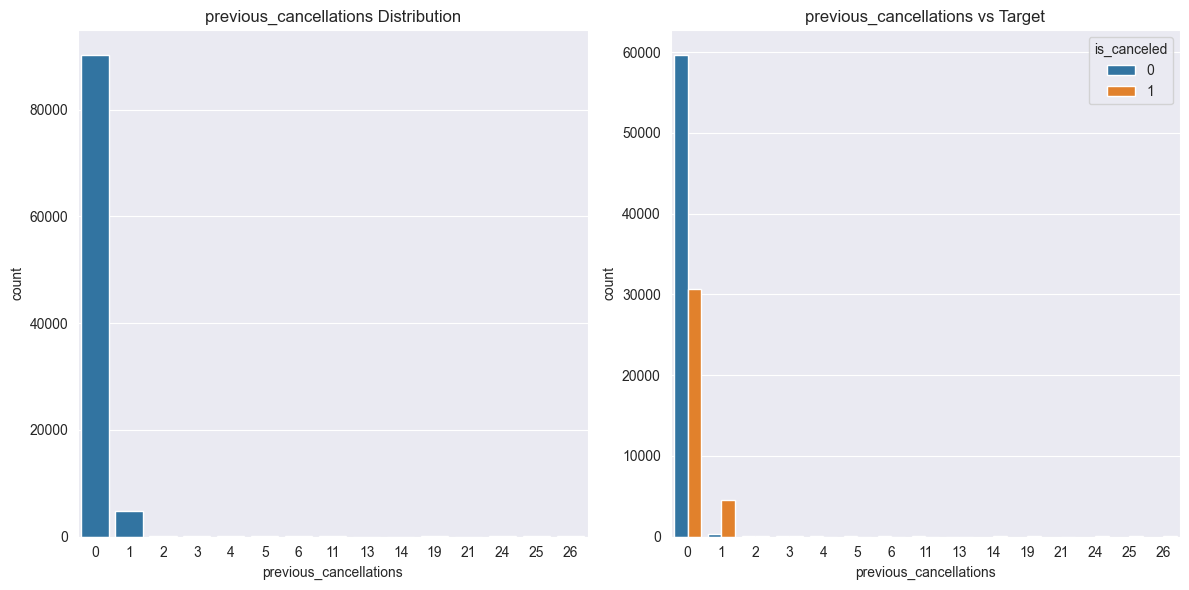

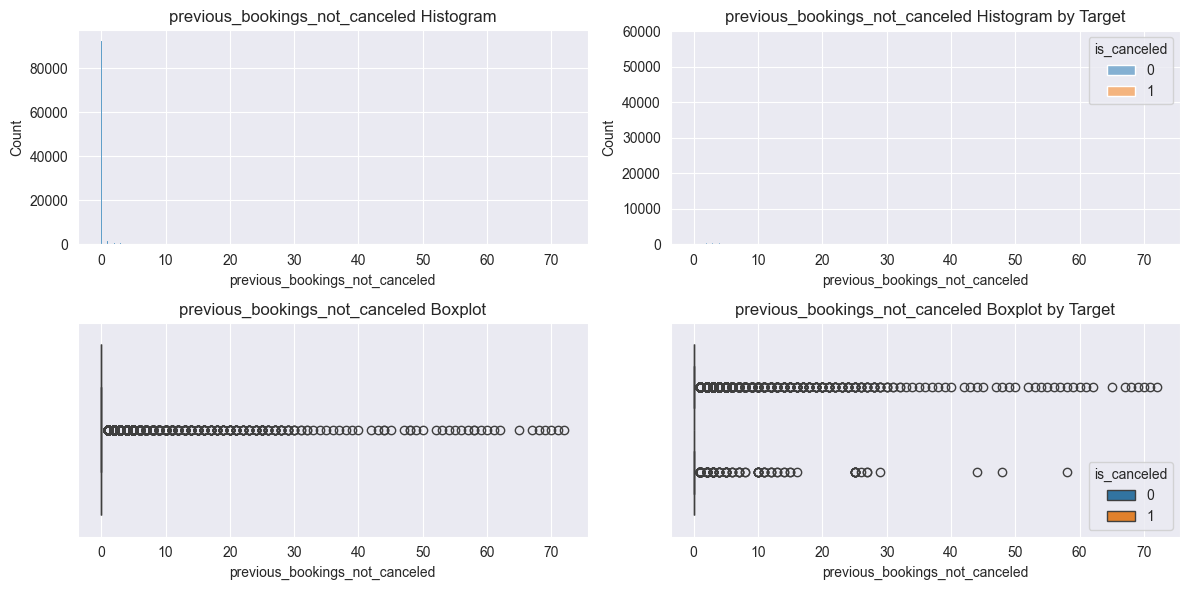

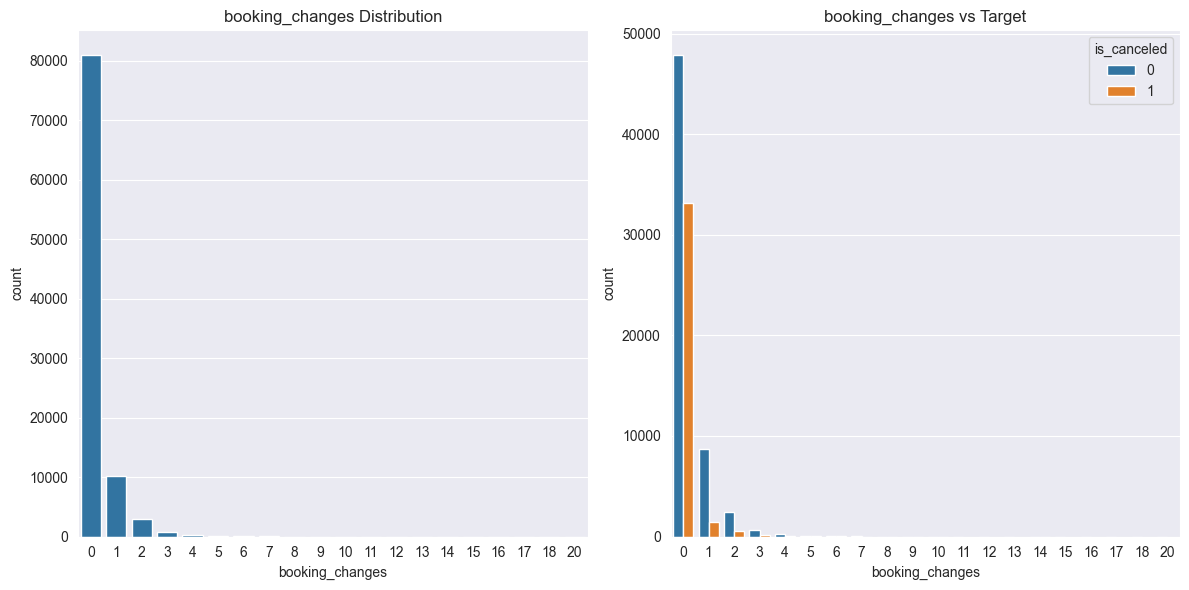

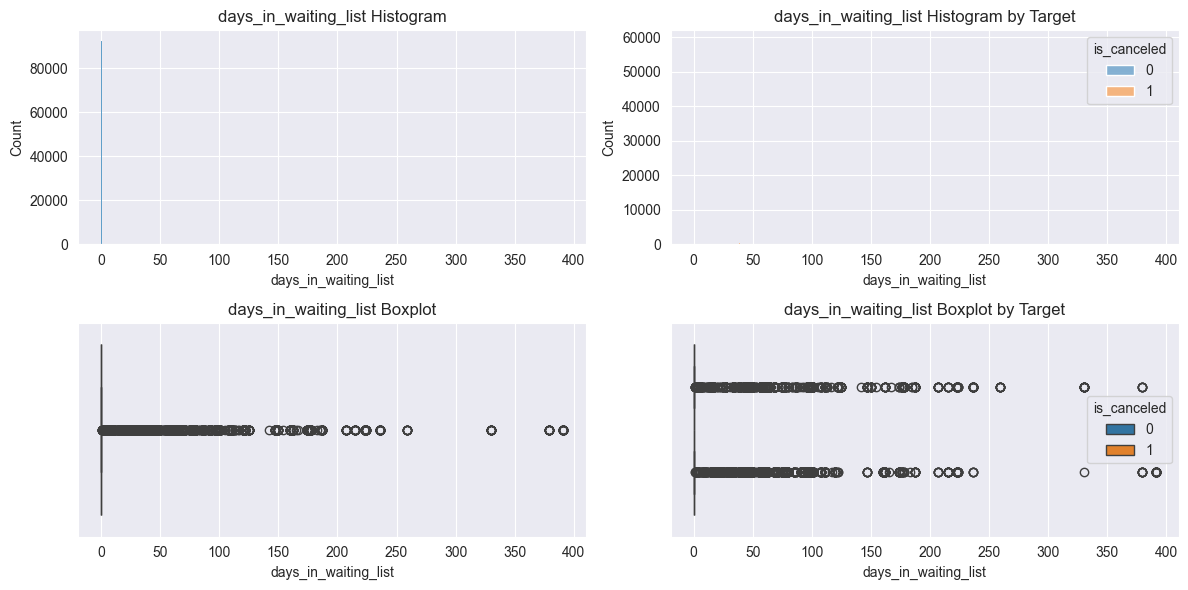

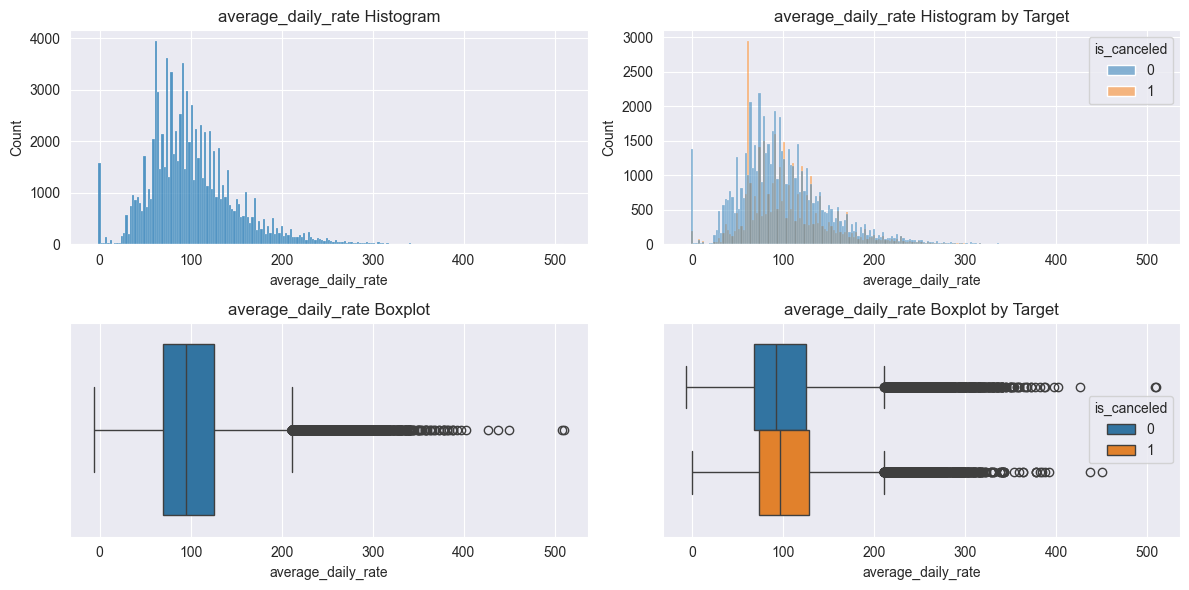

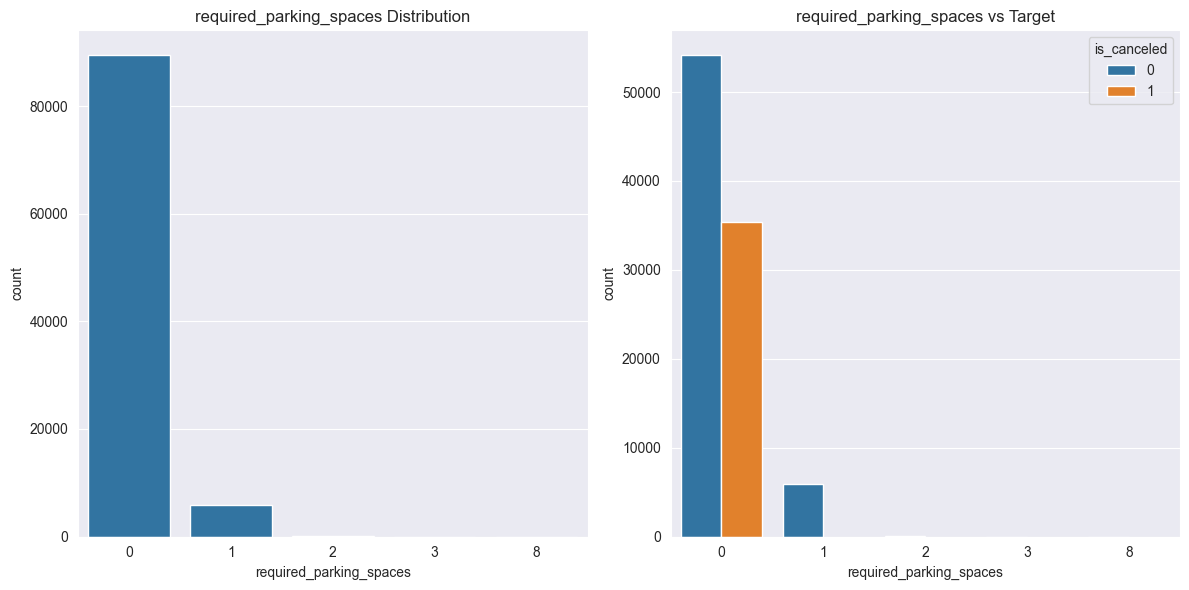

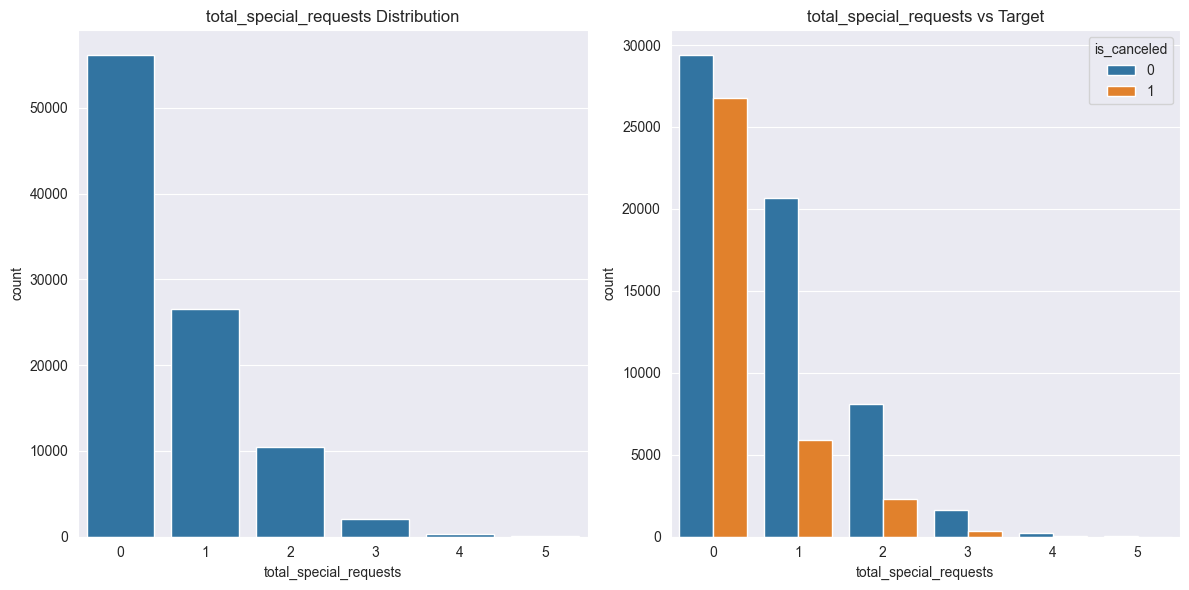

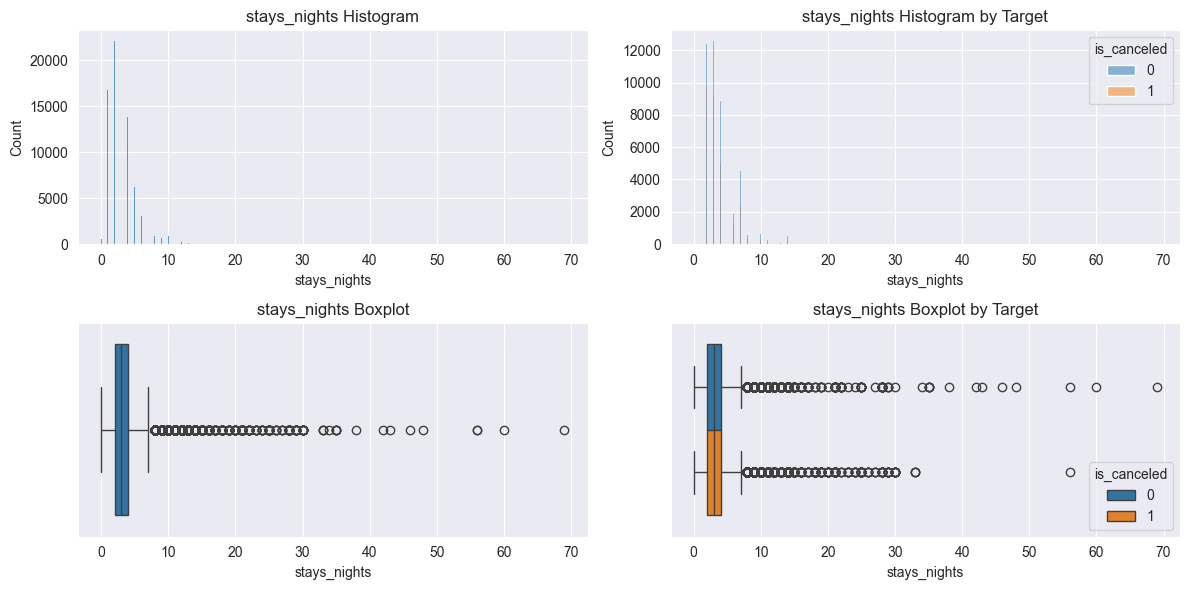

In [17]:
# Check unique values in the dataset to inspect negative values and anomalies
df1['lead_time'].sort_values().unique() 
df1['adults'].sort_values().unique() # Hay reservas con 0 adultos 
df1['children'].sort_values().unique()
df1['babies'].sort_values().unique()
df1['previous_cancellations'].sort_values().unique()
df1['previous_bookings_not_canceled'].sort_values().unique()
df1['booking_changes'].sort_values().unique()
df1['days_in_waiting_list'].sort_values().unique()
df1['average_daily_rate'].sort_values().unique() # Hay precios negativos e igual a 0
df1['required_parking_spaces'].sort_values().unique()
df1['total_special_requests'].sort_values().unique()
df1['stays_nights'].sort_values().unique() # Hay noches igual a 0

# Visualization loop for numerical features using Train set data to avoid leakage
for col in num_cols:
    plt.figure(figsize=(12, 6))
    
    # Low cardinality discrete variables -> Use countplots
    if col not in ['lead_time', 'previous_bookings_not_canceled', 'days_in_waiting_list', 'average_daily_rate', 'stays_nights']:
        plt.subplot(1, 2, 1)
        sns.countplot(data=X_train, x=col)
        plt.title(f'{col} Distribution')
        
        plt.subplot(1, 2, 2)
        sns.countplot(data=X_train, x=col, hue=y_train)
        plt.title(f'{col} vs Target')
        
    # Continuous or high-cardinality variables -> Use Histograms and Boxplots
    else:
        plt.subplot(2, 2, 1)
        sns.histplot(data=X_train, x=col, kde=False)
        plt.title(f'{col} Histogram')
        
        plt.subplot(2, 2, 2)
        sns.histplot(data=X_train, x=col, hue=y_train, kde=False)
        plt.title(f'{col} Histogram by Target')
        
        plt.subplot(2, 2, 3)
        sns.boxplot(data=X_train, x=col)
        plt.title(f'{col} Boxplot')
        
        plt.subplot(2, 2, 4)
        sns.boxplot(data=X_train, x=col , hue=y_train)
        plt.title(f'{col} Boxplot by Target')
        
    plt.tight_layout()
    plt.show()

In [18]:
# Additional data quality checks
X_train['adults'].value_counts()      # Some unusually large values are observed, up to 55 adults
X_train['children'].value_counts()    # Values are concentrated around 0, 1, 2 and 3, with a single extreme value of 10
X_train['babies'].value_counts()      # Most bookings do not include babies, as expected from the distribution

# Check bookings with no guests
empty_bookings = X_train[(X_train['adults'] == 0) & (X_train['children'] == 0) & (X_train['babies'] == 0)]
empty_bookings # 140 bookings contain no adults, children or babies, these observations are considered invalid and will be removed

# Check bookings with more than 6 guests
X_train[(X_train['adults'] + X_train['children'] + X_train['babies']) > 6] # Nearly all observations satisfying this condition have 
# an average daily rate equal to zero, suggesting data quality issues. These records will be removed

# Inspect potentially erroneous prices
X_train.loc[X_train['average_daily_rate'] <= 0, 'average_daily_rate'].count() # There are 1,557 observations with a zero price and one negative value
X_train[(X_train['average_daily_rate'] > 0) & (X_train['average_daily_rate'] < 25)] # A small number of bookings have unusually low prices

# Negative or zero prices are considered invalid and will be removed. The distribution also shows a noticeable gap between zero and approximately
# 20–25 monetary units per night. Given the context of hotel reservations and the concentration of prices around 100, values below 25 are treated as
# potentially erroneous. Since no business validation is available, these observations will also be removed

# Inspect price spikes
X_train[y_train == 1]['average_daily_rate'].value_counts().head()
y_train[X_train['average_daily_rate'] == 62.0].value_counts()

# Several price points exhibit unusually high cancellation rates (price=62). No transformation is applied, as these peaks may reflect genuine booking
# patterns associated with specific promotions, packages or pricing strategies.

# Check bookings with 0 nights
X_train.loc[X_train['stays_nights'] <= 0, 'stays_nights'].count() # There are 566 observations with zero-night stays. These records are
# considered invalid and will be removed

np.int64(566)

### Ordinal Features Analysis

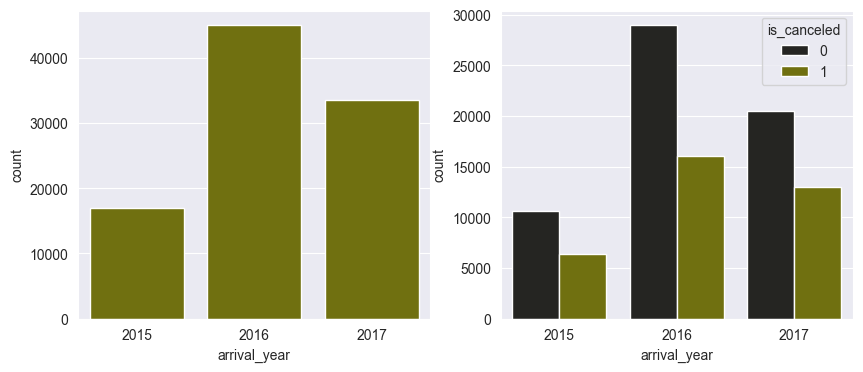

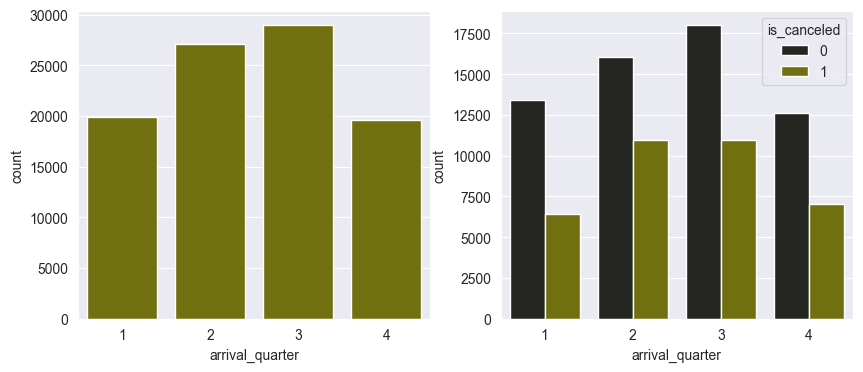

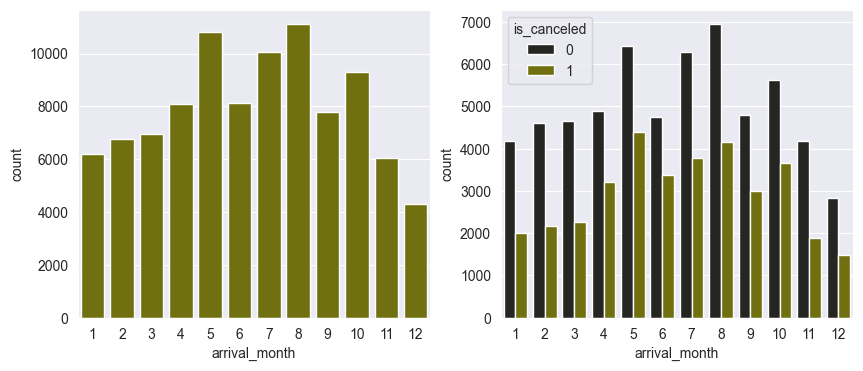

In [19]:
# Visualize ordinal features

for col in ord_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.countplot(data=X_train, x=col, color='olive')
    plt.subplot(1,2,2)
    sns.countplot(data=X_train, x=col, hue=y_train, palette='dark:olive')
    plt.show()

**'arrival_year'**:
Cancellation rates are relatively similar across the three years. Given the low variability and limited information
provided, this feature will be removed.

**'arrival_quarter'**:
Slightly more variability is observed, particularly in the first quarter. However, this feature is highly related to
'arrival_month', which captures seasonality at a finer level of detail. Therefore, 'arrival_quarter' will be removed.

**'arrival_month'**:
Although it may introduce more noise than a quarterly feature, it preserves valuable monthly variation. The feature
will be retained.

### Categorical Features Analysis

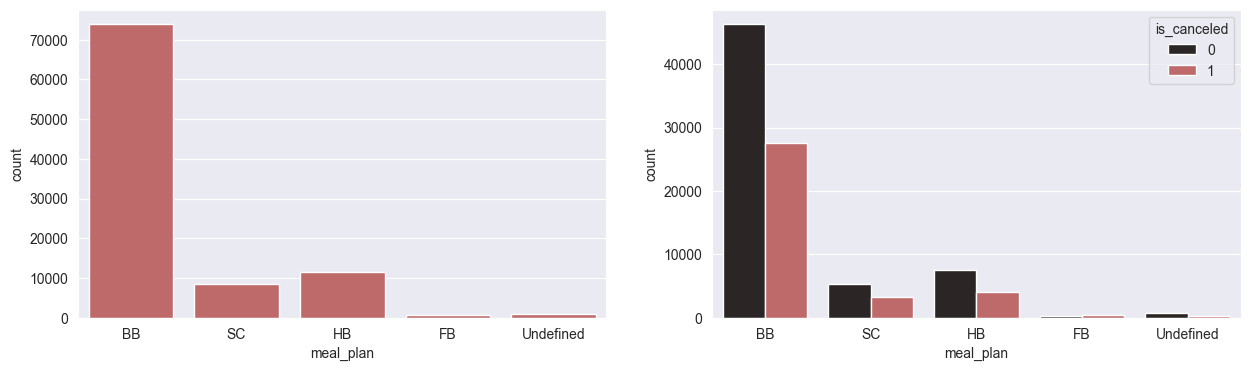

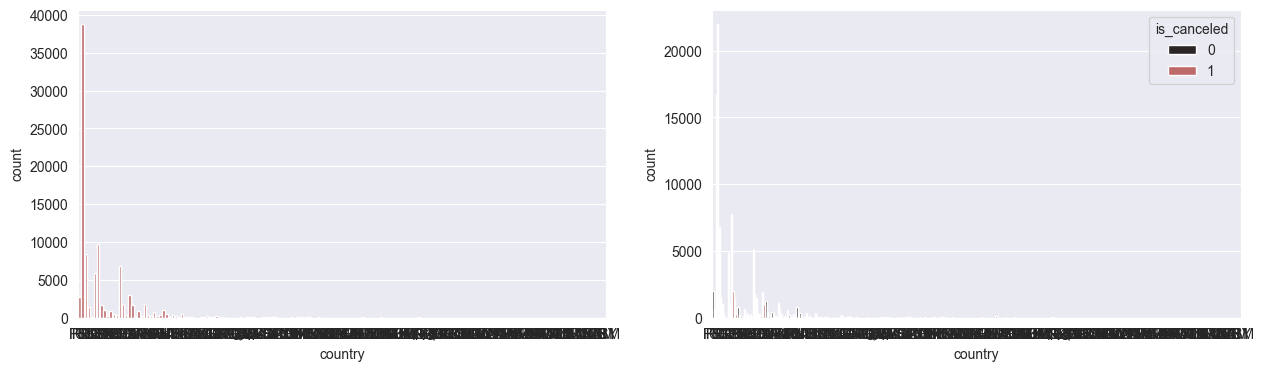

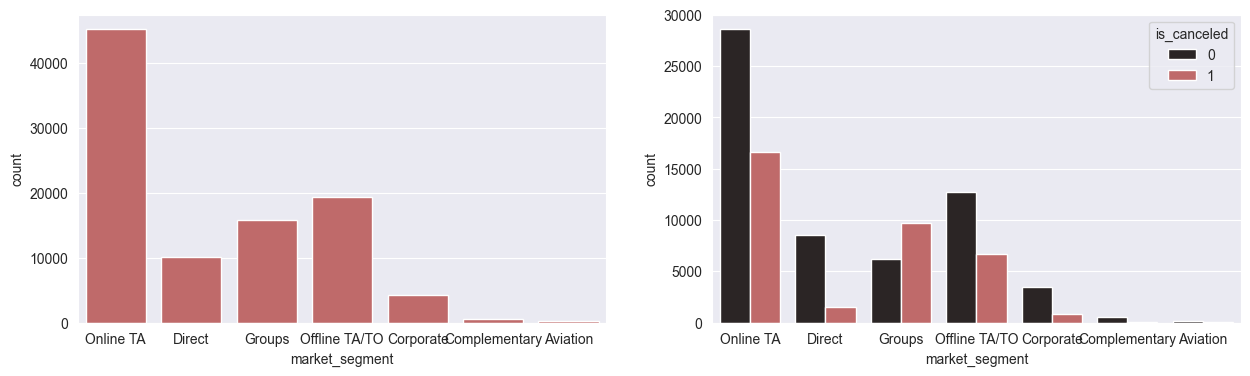

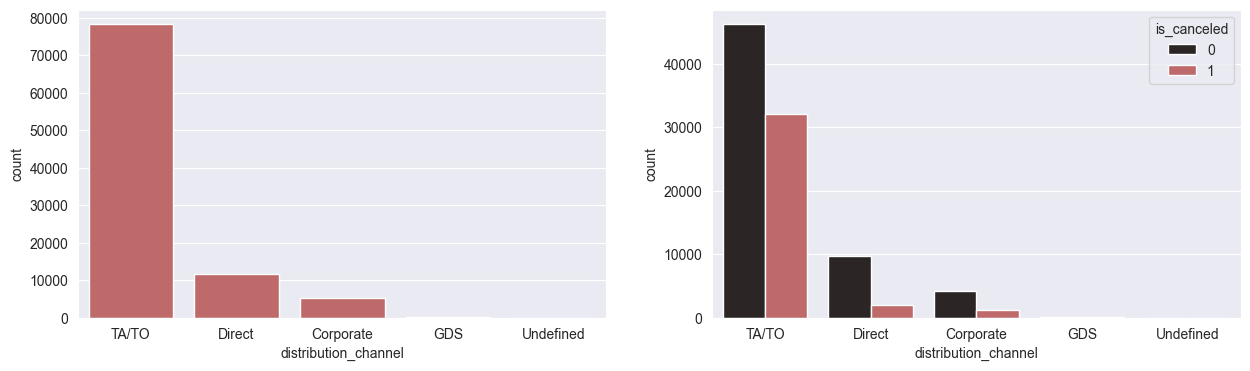

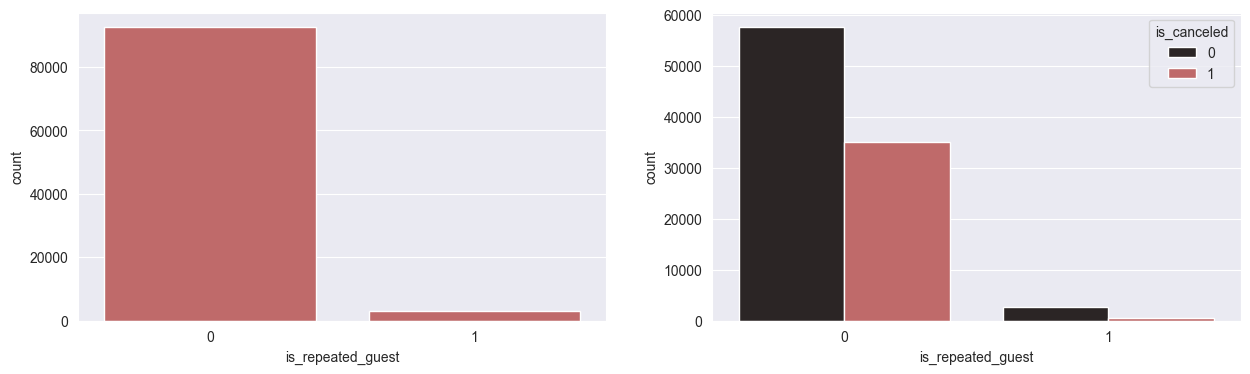

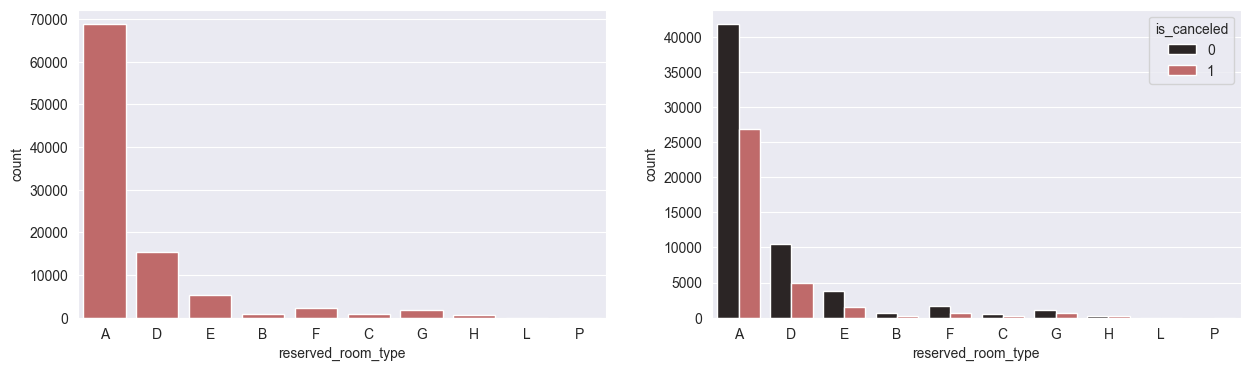

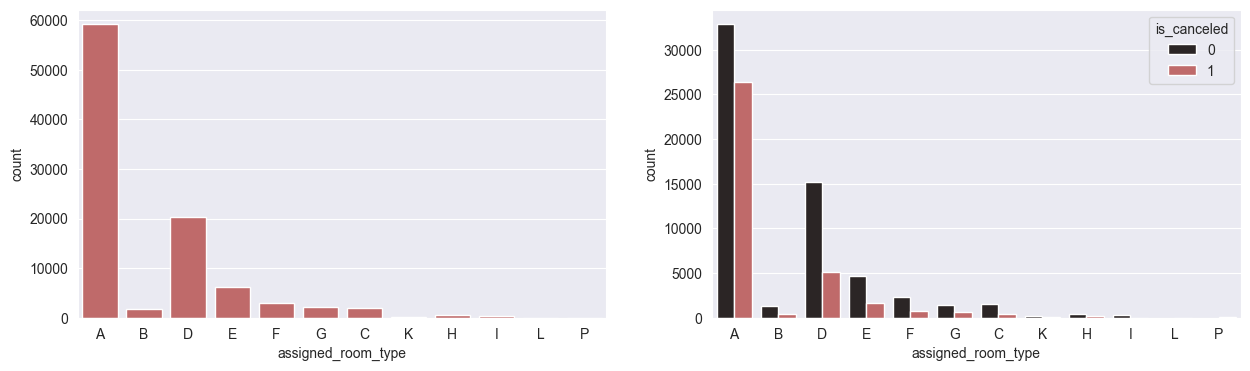

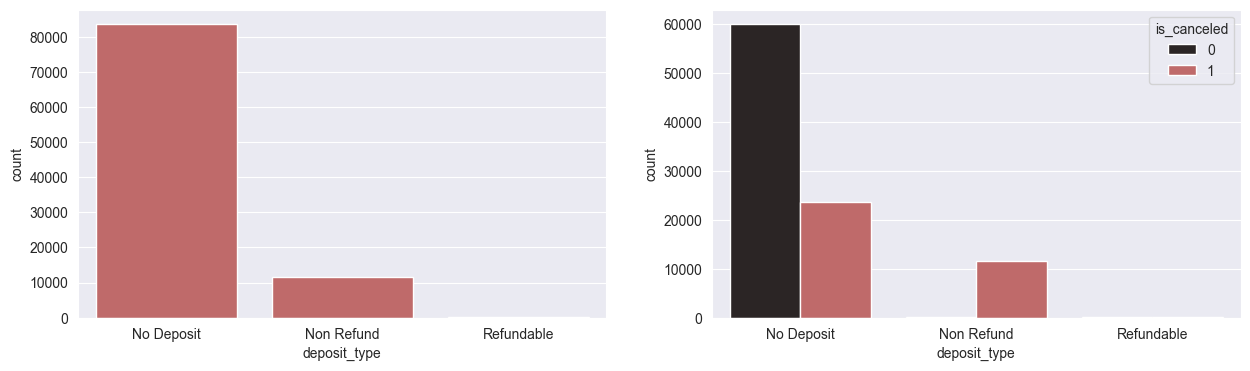

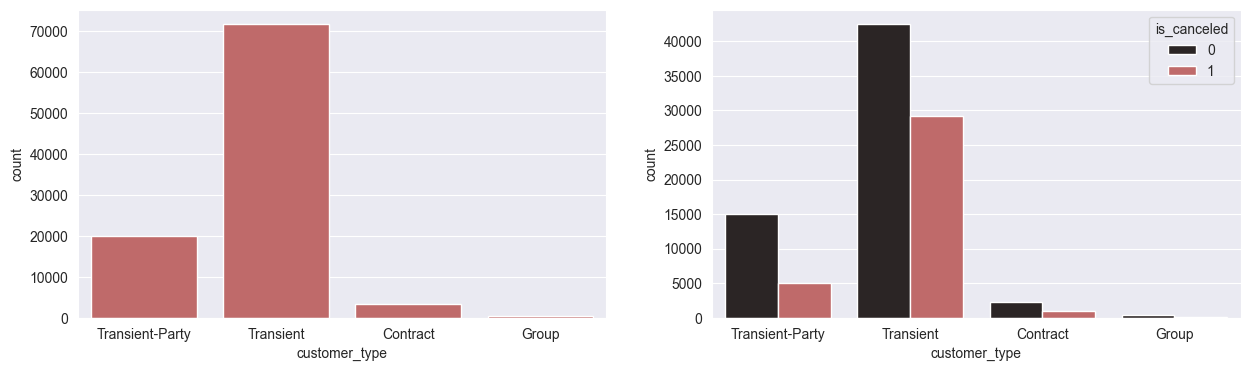

In [20]:
# Visualize categorical features

for col in cat_cols:
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    sns.countplot(data=X_train, x=col, color='indianred')
    plt.subplot(1,2,2)
    sns.countplot(data=X_train, x=col, hue=y_train, palette='dark:indianred')
    plt.show()

**'meal_plan'**:
The category 'Undefined' will be merged with 'SC' (no meal plan).

**'country'**:
This feature has high cardinality. To avoid generating a large number of dummy variables, only the ten most
frequent countries will be retained, while the remaining categories will be grouped into 'Other'.

One-Hot Encoding will be applied to low-cardinality categorical variables: **'meal_plan', 'market_segment', 
'distribution_channel', 'deposit_type'** and **'customer_type'**.

**'reserved_room_type'** and **'assigned_room_type'**: 
Both variables contain multiple categories, with room type 'A' dominating the distribution. One option would
be to keep only the most frequent room types and apply One-Hot Encoding. However, a new binary feature indicating
whether the assigned room differs from the reserved room is expected to be more informative.

Consequently, both room-type variables will be replaced by the feature **'room_change'**.

Additional features such as 'upgrade' and 'downgrade' were considered. However, these would require assuming a
clear hierarchy among room types. Exploratory analysis of room prices showed substantial overlap across room
categories, preventing the definition of a reliable ordering.

Example analysis:
```
log_price = np.log(df1['average_daily_rate'])

sns.boxplot(data=df1, y=log_price, x='reserved_room_type')
```
The overlapping price distributions suggest that room categories do not follow a simple linear hierarchy. 
Therefore, the binary feature 'room_change' is considered sufficient.

### Numerical Features Transformation

In [21]:
X_train.count()  # 95,512 observations

# Remove bookings without guests
mask_train = ~((X_train['adults'] == 0) & (X_train['children'] == 0) & (X_train['babies'] == 0))
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = ~((X_test['adults'] == 0) & (X_test['children'] == 0) & (X_test['babies'] == 0))
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Remove bookings with zero-night stays
mask_train = X_train['stays_nights'] > 0
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test['stays_nights'] > 0
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Remove bookings with suspiciously low prices
mask_train = X_train['average_daily_rate'] >= 25
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test['average_daily_rate'] >= 25
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Remove bookings with unusually large party sizes
X_train[(X_train['adults'] + X_train['children'] + X_train['babies']) > 6] # Only two observations remain after the previous filtering steps

mask_train = (X_train['adults'] + X_train['children'] + X_train['babies']) <= 6
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = (X_test['adults'] + X_test['children'] + X_test['babies']) <= 6
X_test = X_test[mask_test]
y_test = y_test[mask_test]

X_train.count()  # 93,569 observations
1 - (93569 / 95512)

# Approximately 2% of the training observations were removed during the data quality filtering process

0.020342993550548583

In [22]:
# Remove 'babies' due to the extremely high concentration of zero values and limited variability.
X_train.drop(columns='babies', inplace=True)
X_test.drop(columns='babies', inplace=True)
num_cols.remove('babies')

# Convert highly sparse count variables into binary indicators. The objective is to improve interpretability and reduce the influence
# of rare extreme values.

# 'children':
#    0 = no children
#    1 = at least one child

# 'previous_cancellations':
#    0 = no previous cancellations
#    1 = at least one previous cancellation

# 'previous_bookings_not_canceled':
#    0 = no previous completed bookings
#    1 = at least one previous completed booking

# 'booking_changes':
#    0 = no modifications
#    1 = one or more modifications

# 'days_in_waiting_list':
#    0 = not placed on a waiting list
#    1 = placed on a waiting list

# 'required_parking_spaces':
#    0 = no parking requested
#    1 = parking requested

# 'total_special_requests':
#    0 = no special requests
#    1 = one or more special requests

cols_binarizer = [
    ('children', 0),
    ('previous_cancellations', 0),
    ('previous_bookings_not_canceled', 0),
    ('booking_changes', 0),
    ('days_in_waiting_list', 0),
    ('required_parking_spaces', 0),
    ('total_special_requests', 0)
]

for col, threshold in cols_binarizer:
    binarizer = Binarizer(threshold=threshold)
    binarizer.fit(X_train[[col]])

    X_train[col] = binarizer.transform(X_train[[col]])
    X_test[col] = binarizer.transform(X_test[[col]])

    num_cols = [c for c in num_cols if c != col]
    cat_cols.extend([col])

### Ordinal Features Transformation

In [23]:
# Remove 'arrival_year' and 'arrival_quarter'

X_train.drop(columns=['arrival_year', 'arrival_quarter'], inplace=True)
X_test.drop(columns=['arrival_year', 'arrival_quarter'], inplace=True)

# After these removals, 'arrival_month' is the only remaining ordinal feature. It is added to num_cols
# for convenience in subsequent transformations

num_cols.append('arrival_month')

### Categorical Features Transformation

In [24]:
# Merge 'Undefined' and 'SC' categories in 'meal_plan'
X_train['meal_plan'] = X_train['meal_plan'].replace('Undefined', 'SC')
X_test['meal_plan'] = X_test['meal_plan'].replace('Undefined', 'SC')

# Retain only the 10 most frequent countries and group the remaining categories into 'Other'
top_10 = X_train['country'].value_counts().nlargest(10).index
X_train['country'] = X_train['country'].where(X_train['country'].isin(top_10), other='Other')
X_test['country'] = X_test['country'].where(X_test['country'].isin(top_10), other='Other')

# Verify the resulting categories
X_train['country'].unique()

# Apply One-Hot Encoding to low-cardinality categorical features
ohe_cols = [
    'meal_plan',
    'country',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type'
]

for col in ohe_cols:
    # drop='first' avoids perfect multicollinearity
    # handle_unknown='ignore' prevents errors when unseen categories appear     # in the test set
    ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
    ohe.fit(X_train[[col]])

    train_ohe = ohe.transform(X_train[[col]])
    test_ohe = ohe.transform(X_test[[col]])

    df_train_ohe = pd.DataFrame(train_ohe.toarray(), columns=ohe.get_feature_names_out(), index=X_train.index)
    df_test_ohe = pd.DataFrame(test_ohe.toarray(), columns=ohe.get_feature_names_out(), index=X_test.index)

    X_train = X_train.drop(columns=col)
    X_test = X_test.drop(columns=col)

    X_train = X_train.merge(df_train_ohe, left_index=True, right_index=True)
    X_test = X_test.merge(df_test_ohe, left_index=True, right_index=True)

    cat_cols.remove(col)


# Room Change Feature: create a binary feature indicating whether the assigned room differs from the originally reserved room
X_train['room_change'] = (X_train['reserved_room_type'] != X_train['assigned_room_type']).astype(int)
X_test['room_change'] = (X_test['reserved_room_type'] != X_test['assigned_room_type']).astype(int)

# Remove the original room-type variables
X_train.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)
X_test.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)

cat_cols.remove('reserved_room_type')
cat_cols.remove('assigned_room_type')

cat_cols.append('room_change')

 ### Summary of Feature Engineering Decisions
 
 - 'stays_nights': Observations with zero-night stays are removed because they are considered invalid bookings. The distribution is highly right-skewed and contains several extreme values. Outliers are retained for the explanatory model  but will be capped in the predictive model to improve robustness.

- Bookings without guests are removed because they represent invalid records.

- Bookings with more than six guests are removed. Only two observations met this condition, both containing twelve guests. Assuming a single room per reservation, such values appear unrealistic. Their removal also eliminates extreme outliers in both the 'children' and 'babies' variables.

 - 'adults': The variable initially exhibited substantial skewness and extreme values.  After removing invalid observations, the apparent outliers disappear and no further transformation is required. A small number of bookings contain  zero adults; these observations are retained because they may correspond  to reservations linked to other bookings.
 - 'children': The distribution is heavily concentrated at zero. The variable is therefore converted into a binary indicator representing whether children are present in the reservation.
 -'babies':  Due to the overwhelming concentration of observations at zero and the limited variability of the feature, it is removed.

- 'average_daily_rate': Observations with negative, zero or extremely low prices are removed because they are likely data quality issues. The distribution suggests a discontinuity between values close to zero and the main mass of the data. A Box-Cox transformation will later be applied in the predictive model to reduce skewness and improve model performance.

- 'lead_time': The variable presents a long right tail. No transformation is applied in the explanatory model to preserve interpretability. A Yeo-Johnson transformation will be applied in the predictive model to reduce skewness.
 
 - 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'required_parking_spaces': These variables are converted into binary indicators because most observations are concentrated at zero.

 - 'total_special_requests': Converted into a binary indicator due to the strong concentration at zero and the noticeable difference in cancellation rates between bookings with and without special requests. Numerical feature scaling is postponed until the predictive modelling stage,
 as standardization is not required for interpretation purposes.

 - 'arrival_year': Removed because cancellation rates are similar across years and the feature provides limited explanatory value.
 - 'arrival_quarter': Removed due to its strong overlap with 'arrival_month', which captures seasonality at a more detailed level.
 - 'arrival_month': Retained because it preserves monthly seasonal patterns that may be associated with cancellation behaviour.

- 'meal_plan': The 'Undefined' category is merged with 'SC' because both categories represent the same booking condition according to the dataset description.

 - 'country': Only the ten most frequent countries are retained, while the remaining categories are grouped into 'Other' to reduce cardinality before
 applying One-Hot Encoding.

 - One-Hot Encoding is applied to: 'meal_plan', 'market_segment', 'distribution_channel', 'deposit_type' and 'customer_type'.

 - 'is_repeated_guest': No transformation is required because the feature is already binary.

 - 'room_change': A new binary feature indicating whether the assigned room differs from the reserved room. The original room-type variables are removed because of their high cardinality and limited standalone interpretability.

 - 'distribution_channel': This variable is expected to be highly correlated with 'market_segment'. For the predictive model, regularization will be used to handle potential multicollinearity. For the explanatory model, the dummy variables derived from 'distribution_channel' will be removed because 'market_segment' provides a clearer interpretation of booking behaviour.

### Post-Transformation Feature Inspection

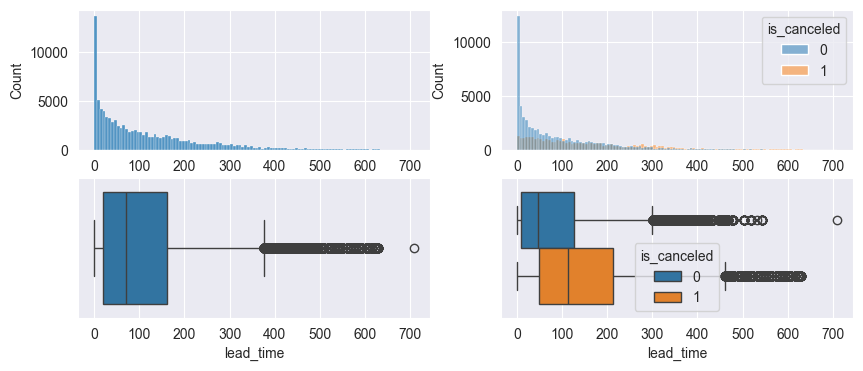

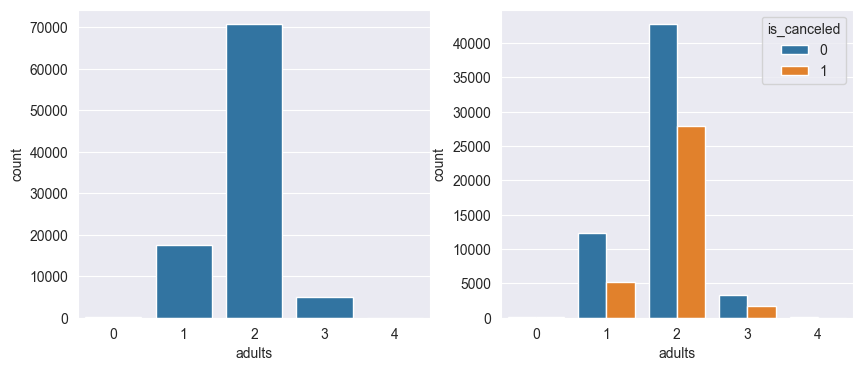

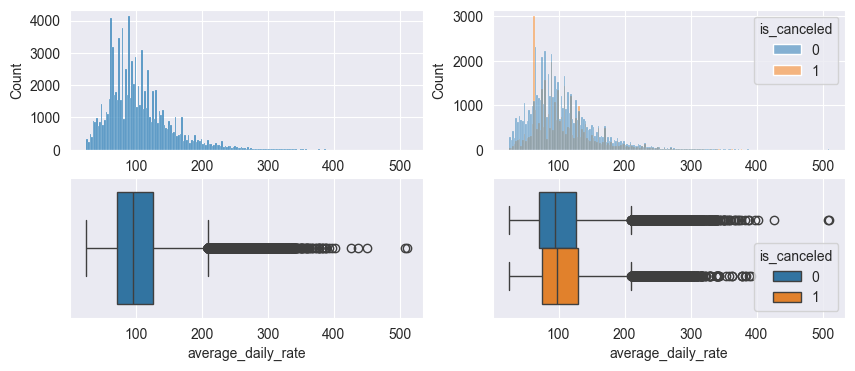

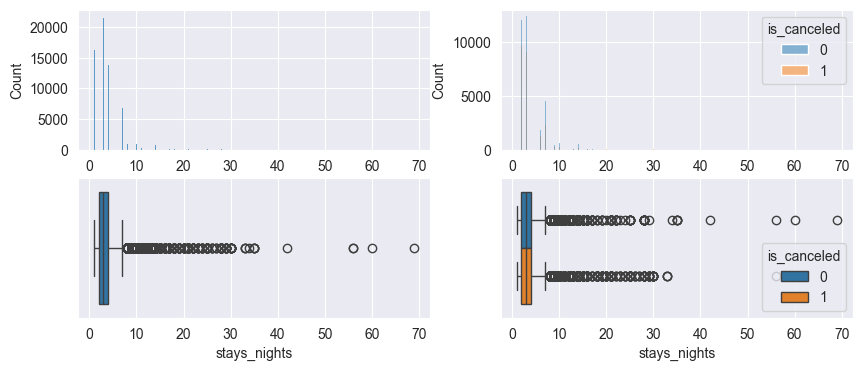

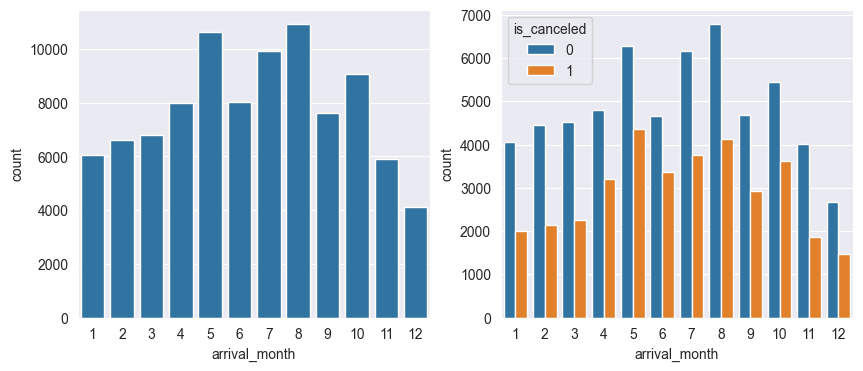

In [26]:
# All variables are visualized again after the feature engineering process to verify that the transformations were 
# applied correctly and to evaluate whether the resulting distributions are suitable for modelling

# Visualize numerical features

# For numerical variables with a small number of unique values (e.g. 'adults' and 'arrival_month'), count plots are 
# preferred because they provide a more informative representation than histograms. For continuous numerical variables,
# both histograms and boxplots are used to assess the distribution, class separation and potential remaining outliers
for col in num_cols:
    plt.figure(figsize=(10,4))
    if X_train[col].nunique() <= 12:
        plt.subplot(1,2,1)
        sns.countplot(data=X_train, x=col)
        plt.subplot(1,2,2)
        sns.countplot(data=X_train, x=col, hue=y_train)
    else:
        plt.subplot(2,2,1)
        sns.histplot(data=X_train, x=col)
        plt.subplot(2,2,2)
        sns.histplot(data=X_train, x=col, hue=y_train)
        plt.subplot(2,2,3)
        sns.boxplot(data=X_train, x=col)
        plt.subplot(2,2,4)
        sns.boxplot(data=X_train, x=col, hue=y_train)
    plt.show()

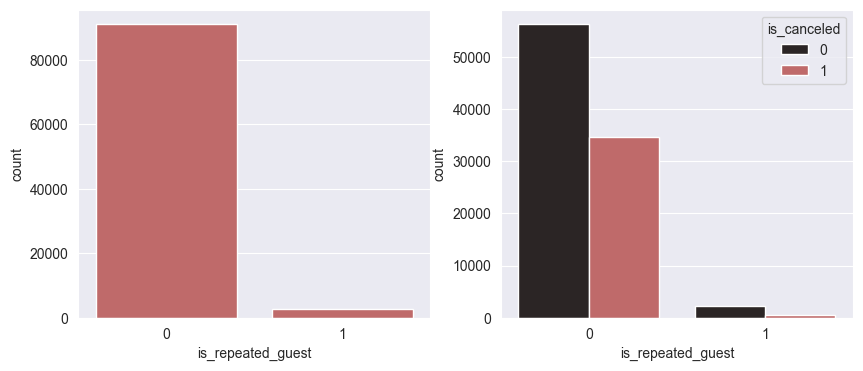

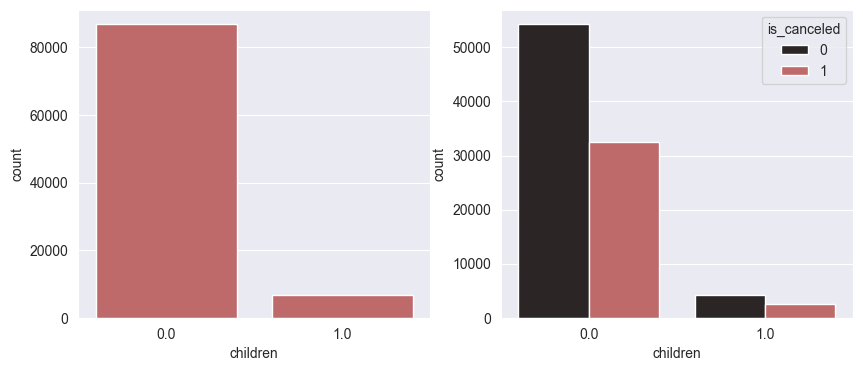

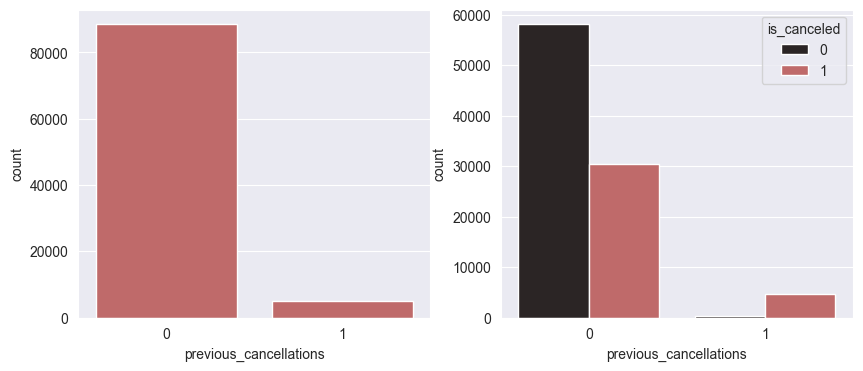

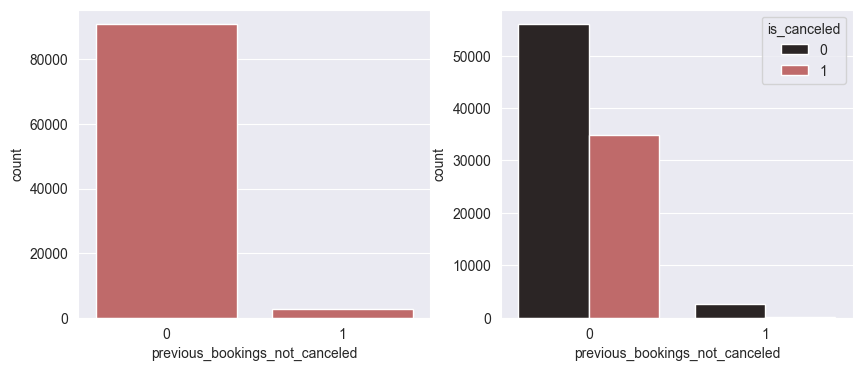

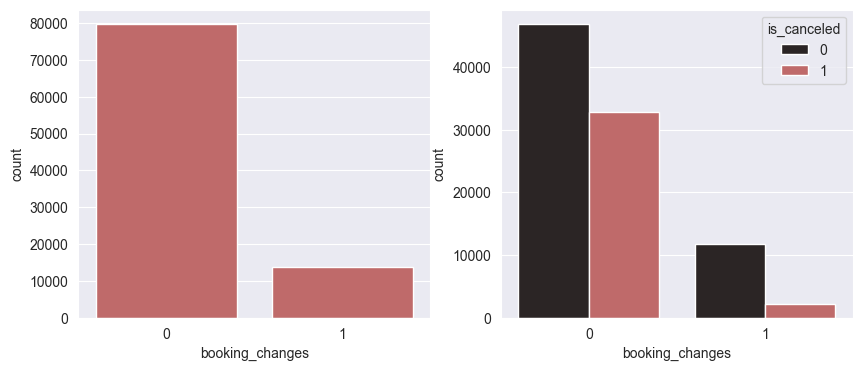

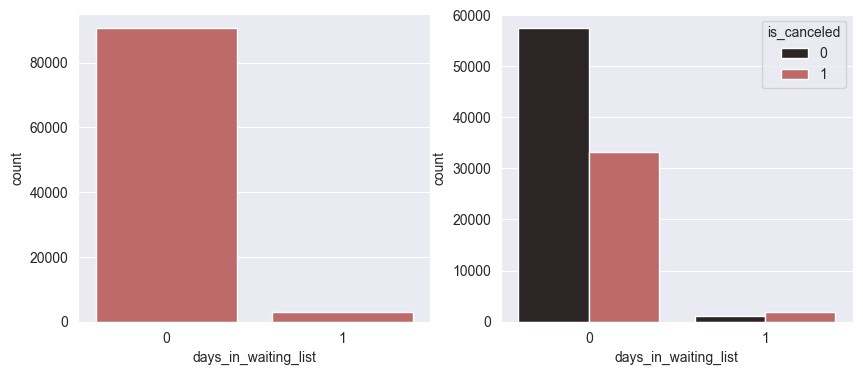

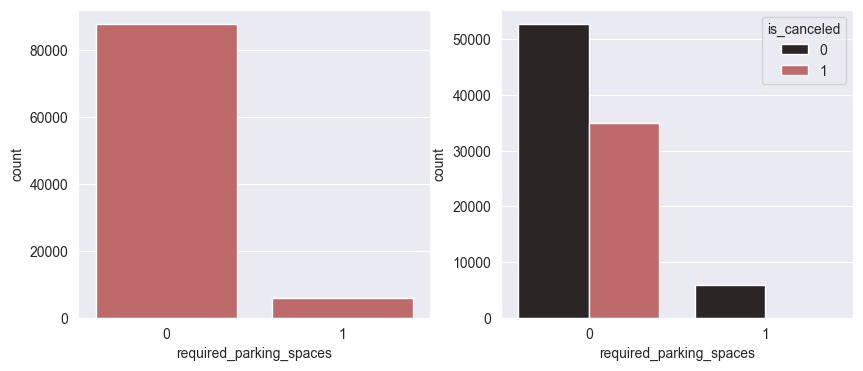

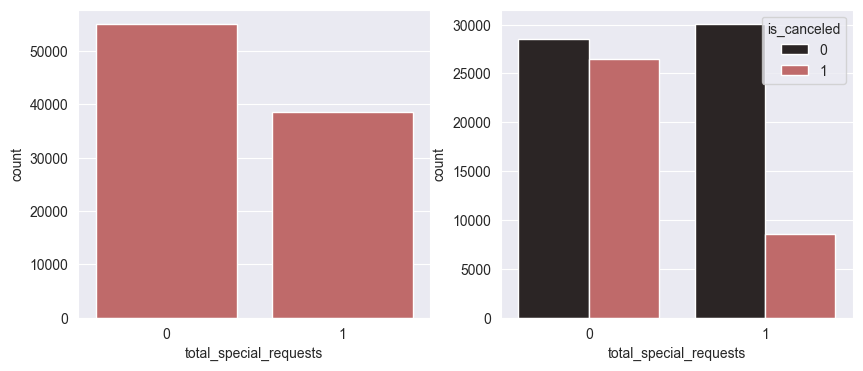

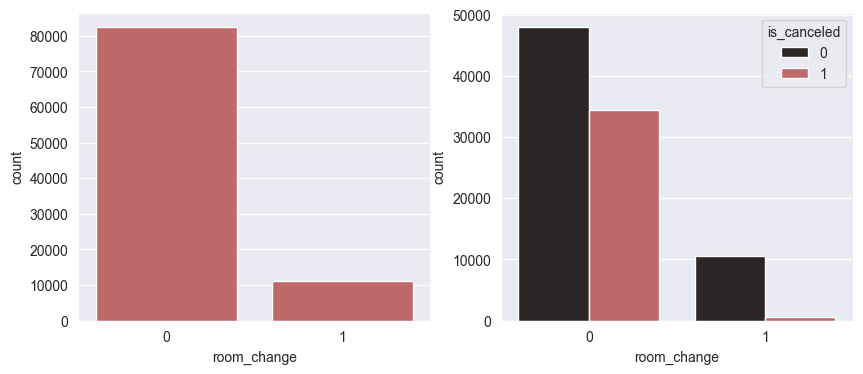

In [27]:
# Visualize categorical features
for col in cat_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.countplot(data=X_train, x=col, color='indianred')
    plt.subplot(1,2,2)
    sns.countplot(data=X_train, x=col, hue=y_train, palette='dark:indianred')
    plt.show()

# 4. Explanatory Logistic Regression Model

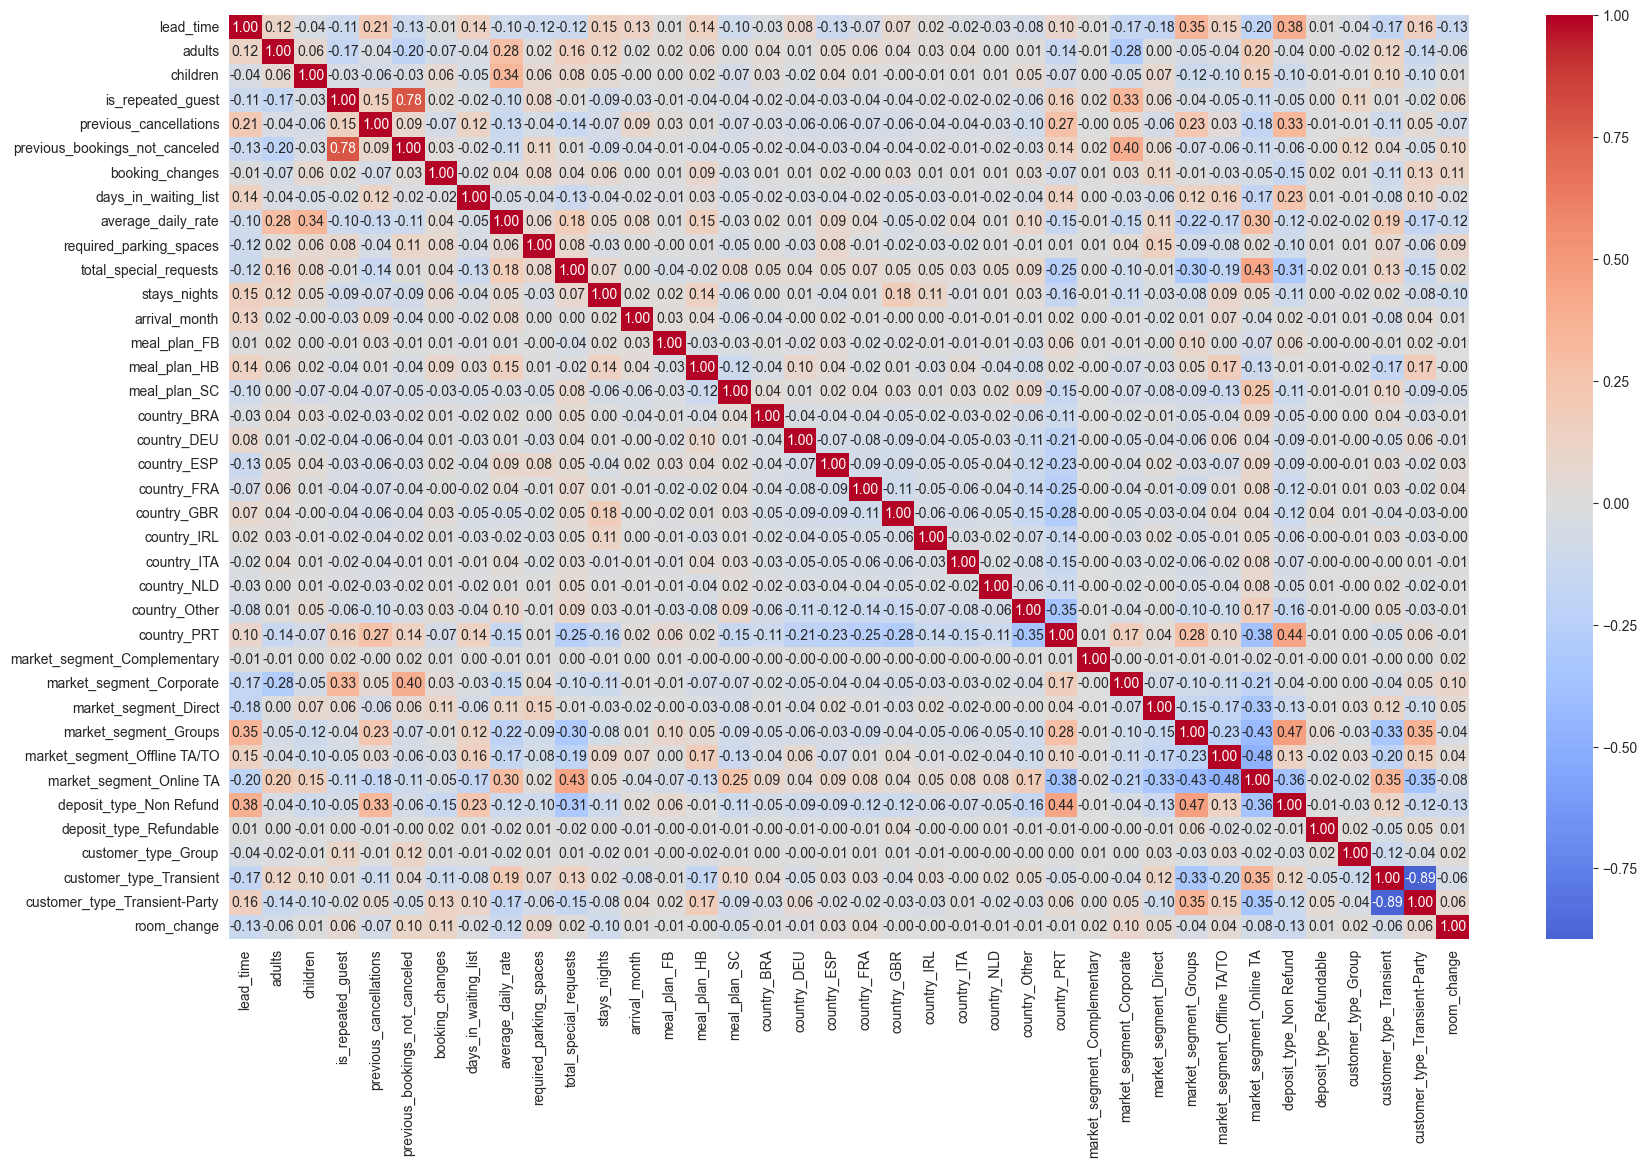

In [28]:
# Remove distribution channel variables
X_train_exp = X_train.drop(columns=['distribution_channel_Direct', 'distribution_channel_GDS', 
                                    'distribution_channel_TA/TO', 'distribution_channel_Undefined'])
X_test_exp = X_test.drop(columns=['distribution_channel_Direct', 'distribution_channel_GDS',
                                  'distribution_channel_TA/TO', 'distribution_channel_Undefined'])

# Prior to fitting the explanatory model, summary statistics and correlation analyses are performed
X_train_exp.describe() # Outliers are still present in 'lead_time', 'average_daily_rate' and 'stays_nights'.
# They are retained because they may contain meaningful information and do not appear to be data entry errors

# Explore the relationship between predictors and the target
X_train_exp.corrwith(y_train).abs().sort_values() # No variables are removed at this stage solely based on correlation.
# Statistical significance and model diagnostics will be considered during model fitting

# Correlation matrix
plt.figure(figsize=(20, 12))
sns.heatmap(
    X_train_exp.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.show()

# 'previous_bookings_not_canceled' and 'is_repeated_guest' exhibit a strong correlation. This relationship is expected 
# because a customer must have completed previous bookings in order to be considered a repeated guest. Since 
# 'previous_bookings_not_canceled' contains more detailed information, 'is_repeated_guest' will be removed from the model

# 'customer_type_Transient-Party' and 'customer_type_Transient' also show substantial correlation. However, this is largely a
# consequence of the One-Hot Encoding process and the relatively small number of observations belonging to the reference category

# Both variables are retained for the moment and will be reassessed later if large standard errors or multicollinearity issues arise

### Model 1

In [29]:
# Remove 'is_repeated_guest' due to its strong overlap with 'previous_bookings_not_canceled'
X = X_train_exp.drop(columns='is_repeated_guest')
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

         Current function value: 0.371212
         Iterations: 35


C:\Users\zaida\anaconda3\envs\datamining_predictivemodeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93531
Method:                           MLE   Df Model:                           37
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.4387
Time:                        17:26:59   Log-Likelihood:                -34734.
converged:                      False   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -3.8350      0.226    -16.993      0.000      -4.277      -3.393
lead_time                          0.0054      0.000     44.603      0.000       0.005       0.006
adults                             0.0886      0.022      4.097      0.000       0.046       0.131
children                           0.1395      0.036      3.910      0.000       0.070       0.209
previous_cancellations             3.9958      0.140     28.560      0.000       3.722       4.270
previous_bookings_not_canceled    -3.3167      0.157    -21.069      0.000      -3.625      -3.008
booking_changes                   -0.7886      0.030    -26.273      0.000      -0.847      -0.730
days_in_waiting_list              -0.3574      0.080     -4.448      0.000      -0.515      -0.200
average_daily_rate                 0.0043      0.000     17.697      0.000       0.004       0.005
required_parking_spaces          -27.4891   1.57e+04     -0.002      0.999   -3.08e+04    3.07e+04
total_special_requests            -1.2600      0.021    -59.773      0.000      -1.301      -1.219
stays_nights                       0.0640      0.004     16.343      0.000       0.056       0.072
arrival_month                     -0.0114      0.003     -3.575      0.000      -0.018      -0.005
meal_plan_FB                       0.2187      0.131      1.669      0.095      -0.038       0.476
meal_plan_HB                      -0.2025      0.033     -6.155      0.000      -0.267      -0.138
meal_plan_SC                       0.2002      0.028      7.077      0.000       0.145       0.256
country_BRA                        0.9643      0.087     11.057      0.000       0.793       1.135
country_DEU                       -0.2489      0.076     -3.273      0.001      -0.398      -0.100
country_ESP                        0.8017      0.073     10.916      0.000       0.658       0.946
country_FRA                        0.1154      0.072      1.595      0.111      -0.026       0.257
country_GBR                        0.0705      0.071      0.986      0.324      -0.070       0.210
country_IRL                        0.1679      0.083      2.021      0.043       0.005       0.331
country_ITA                        0.9409      0.079     11.888      0.000       0.786       1.096
country_NLD                       -0.0194      0.095     -0.203      0.839      -0.206       0.167
country_Other                      0.5187      0.068      7.581      0.000       0.385       0.653
country_PRT                        2.0231      0.068     29.627      0.000       1.889       2.157
market_segment_Complementary      -0.4126      0.853     -0.484      0.628      -2.083       1.258
market_segment_Corporate          -0.4441      0.208     -2.134      0.033      -0.852      -0.036
market_segment_Direct             -0.3982      0.203     -1.959      0.050      -0.797       0.000
market_segment_Groups             -0.0912      0.206     -0.443      0.65

### Model 2

In [30]:
# Remove the variable with the largest standard error to assess whether model convergence and coefficient stability improve

X = X_train_exp.drop(columns=['is_repeated_guest', 'required_parking_spaces'])
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.390562
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93532
Method:                           MLE   Df Model:                           36
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.4094
Time:                        17:27:00   Log-Likelihood:                -36544.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -3.6778      0.222    -16.539      0.000      -4.114      -3.242
lead_time                          0.0054      0.000     46.106      0.000       0.005       0.006
adults                             0.0584      0.021      2.744      0.006       0.017       0.100
children                           0.0629      0.034      1.837      0.066      -0.004       0.130
previous_cancellations             4.0414      0.136     29.651      0.000       3.774       4.309
previous_bookings_not_canceled    -3.4564      0.154    -22.499      0.000      -3.757      -3.155
booking_changes                   -0.8405      0.029    -28.663      0.000      -0.898      -0.783
days_in_waiting_list              -0.3303      0.080     -4.134      0.000      -0.487      -0.174
average_daily_rate                 0.0038      0.000     16.281      0.000       0.003       0.004
total_special_requests            -1.2530      0.021    -61.056      0.000      -1.293      -1.213
stays_nights                       0.0631      0.004     16.543      0.000       0.056       0.071
arrival_month                     -0.0127      0.003     -4.053      0.000      -0.019      -0.007
meal_plan_FB                       0.1597      0.126      1.267      0.205      -0.087       0.407
meal_plan_HB                      -0.2263      0.032     -7.099      0.000      -0.289      -0.164
meal_plan_SC                       0.2567      0.028      9.204      0.000       0.202       0.311
country_BRA                        0.9288      0.086     10.840      0.000       0.761       1.097
country_DEU                       -0.2505      0.075     -3.330      0.001      -0.398      -0.103
country_ESP                        0.6577      0.072      9.121      0.000       0.516       0.799
country_FRA                        0.0979      0.072      1.370      0.171      -0.042       0.238
country_GBR                        0.0597      0.071      0.845      0.398      -0.079       0.198
country_IRL                        0.1911      0.082      2.323      0.020       0.030       0.352
country_ITA                        0.9480      0.078     12.131      0.000       0.795       1.101
country_NLD                       -0.0653      0.094     -0.696      0.487      -0.249       0.119
country_Other                      0.4984      0.068      7.375      0.000       0.366       0.631
country_PRT                        1.8792      0.067     27.950      0.000       1.747       2.011
market_segment_Complementary      -0.3170      0.843     -0.376      0.707      -1.969       1.335
market_segment_Corporate          -0.4612      0.205     -2.246      0.025      -0.864      -0.059
market_segment_Direct             -0.5443      0.201     -2.714      0.007      -0.937      -0.151
market_segment_Groups             -0.0824      0.203     -0.406      0.685      -0.480       0.316
market_segment_Offline TA/TO      -0.4953      0.200     -2.471      0.01

### Model 3

In [31]:
# Remove variables with p-values greater than 0.05 in order to obtain a more parsimonious explanatory model
X = X_train_exp.drop(columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.390621
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93541
Method:                           MLE   Df Model:                           27
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.4093
Time:                        17:27:01   Log-Likelihood:                -36550.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -3.6973      0.093    -39.639      0.000      -3.880      -3.515
lead_time                          0.0054      0.000     46.448      0.000       0.005       0.006
adults                             0.0552      0.021      2.616      0.009       0.014       0.097
previous_cancellations             4.0418      0.136     29.645      0.000       3.775       4.309
previous_bookings_not_canceled    -3.4572      0.154    -22.503      0.000      -3.758      -3.156
booking_changes                   -0.8377      0.029    -28.611      0.000      -0.895      -0.780
days_in_waiting_list              -0.3324      0.080     -4.163      0.000      -0.489      -0.176
average_daily_rate                 0.0040      0.000     17.961      0.000       0.004       0.004
total_special_requests            -1.2546      0.021    -61.170      0.000      -1.295      -1.214
stays_nights                       0.0634      0.004     16.684      0.000       0.056       0.071
arrival_month                     -0.0129      0.003     -4.128      0.000      -0.019      -0.007
meal_plan_HB                      -0.2303      0.032     -7.254      0.000      -0.293      -0.168
meal_plan_SC                       0.2528      0.028      9.106      0.000       0.198       0.307
country_BRA                        0.8733      0.060     14.551      0.000       0.756       0.991
country_DEU                       -0.3103      0.044     -7.100      0.000      -0.396      -0.225
country_ESP                        0.6008      0.038     15.710      0.000       0.526       0.676
country_IRL                        0.1321      0.055      2.406      0.016       0.024       0.240
country_ITA                        0.8898      0.049     18.271      0.000       0.794       0.985
country_Other                      0.4405      0.029     15.357      0.000       0.384       0.497
country_PRT                        1.8227      0.027     66.330      0.000       1.769       1.877
market_segment_Corporate          -0.3883      0.070     -5.573      0.000      -0.525      -0.252
market_segment_Direct             -0.4689      0.054     -8.742      0.000      -0.574      -0.364
market_segment_Offline TA/TO      -0.4175      0.043     -9.623      0.000      -0.503      -0.332
market_segment_Online TA           1.2306      0.046     26.598      0.000       1.140       1.321
deposit_type_Non Refund            4.6938      0.125     37.654      0.000       4.449       4.938
customer_type_Transient            1.1096      0.068     16.368      0.000       0.977       1.242
customer_type_Transient-Party      0.5420      0.073      7.474      0.000       0.400       0.684
room_change                       -1.8615      0.047    -39.761      0.000      -1.953      -1.770
==================================================================================================
"""

### Variance Inflation Factor (VIF)

In [32]:
# Evaluate multicollinearity among predictors
for ii, col in enumerate(X_train_exp.columns):
    vif = variance_inflation_factor(X_train.values, ii)
    print(f"{col}: {vif:.2f}")

lead_time: 3.00
adults: 20.04
children: 1.25
is_repeated_guest: 2.71
previous_cancellations: 1.33
previous_bookings_not_canceled: 2.85
booking_changes: 1.28
days_in_waiting_list: 1.14
average_daily_rate: 8.95
required_parking_spaces: 1.14
total_special_requests: 2.26
stays_nights: 3.40
arrival_month: 5.58
meal_plan_FB: 1.04
meal_plan_HB: 1.34
meal_plan_SC: 1.24
country_BRA: 1.89
country_DEU: 3.94
country_ESP: 4.44
country_FRA: 5.17
country_GBR: 5.85
country_IRL: 2.35
country_ITA: 2.50
country_NLD: 1.85
country_Other: 8.38
country_PRT: 20.38
market_segment_Complementary: 1.04
market_segment_Corporate: 5.11
market_segment_Direct: 21.54
market_segment_Groups: 26.28
market_segment_Offline TA/TO: 32.47
market_segment_Online TA: 77.59
deposit_type_Non Refund: 12.40
deposit_type_Refundable: 1.11
customer_type_Group: 54.14
customer_type_Transient: 1.00
customer_type_Transient-Party: 2.78
room_change: 1.03


### Model 4

In [33]:
# Remove predictors exhibiting severe multicollinearity (VIF greater than 10)
X = X_train_exp.drop(
    columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group',
        'adults',
        'country_PRT',
        'market_segment_Direct',
        'market_segment_Offline TA/TO',
        'market_segment_Online TA',
        'deposit_type_Non Refund'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.471986
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93547
Method:                           MLE   Df Model:                           21
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2863
Time:                        17:27:30   Log-Likelihood:                -44163.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.1815      0.072    -30.407      0.000      -2.322      -2.041
lead_time                          0.0061   9.48e-05     64.348      0.000       0.006       0.006
previous_cancellations             4.7687      0.131     36.289      0.000       4.511       5.026
previous_bookings_not_canceled    -4.3729      0.163    -26.762      0.000      -4.693      -4.053
booking_changes                   -1.0522      0.028    -38.232      0.000      -1.106      -0.998
days_in_waiting_list               0.3903      0.054      7.273      0.000       0.285       0.495
average_daily_rate                 0.0045      0.000     23.728      0.000       0.004       0.005
total_special_requests            -1.2622      0.018    -71.090      0.000      -1.297      -1.227
stays_nights                      -0.0029      0.003     -0.854      0.393      -0.010       0.004
arrival_month                     -0.0232      0.003     -8.300      0.000      -0.029      -0.018
meal_plan_HB                      -0.1760      0.027     -6.411      0.000      -0.230      -0.122
meal_plan_SC                       0.2026      0.027      7.639      0.000       0.151       0.255
country_BRA                       -0.0600      0.057     -1.055      0.291      -0.171       0.051
country_DEU                       -1.4314      0.040    -36.234      0.000      -1.509      -1.354
country_ESP                       -0.4393      0.033    -13.269      0.000      -0.504      -0.374
country_IRL                       -0.9287      0.052    -17.981      0.000      -1.030      -0.827
country_ITA                       -0.1094      0.045     -2.448      0.014      -0.197      -0.022
country_Other                     -0.5689      0.023    -24.323      0.000      -0.615      -0.523
market_segment_Corporate          -0.2418      0.053     -4.568      0.000      -0.346      -0.138
customer_type_Transient            1.9005      0.065     29.363      0.000       1.774       2.027
customer_type_Transient-Party      0.5930      0.067      8.789      0.000       0.461       0.725
room_change                       -2.0664      0.044    -46.821      0.000      -2.153      -1.980
==================================================================================================
"""

### Model 5

In [34]:
# Starting from Model 4, remove predictors that remain statistically non-significant (p-value > 0.05)
X = X_train_exp.drop(
    columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group',
        'adults',
        'country_PRT',
        'market_segment_Direct',
        'market_segment_Offline TA/TO',
        'market_segment_Online TA',
        'deposit_type_Non Refund',
        'stays_nights',
        'country_BRA'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.471996
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93549
Method:                           MLE   Df Model:                           19
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2863
Time:                        17:27:31   Log-Likelihood:                -44164.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.2004      0.069    -32.098      0.000      -2.335      -2.066
lead_time                          0.0061   9.32e-05     65.288      0.000       0.006       0.006
previous_cancellations             4.7743      0.131     36.356      0.000       4.517       5.032
previous_bookings_not_canceled    -4.3749      0.163    -26.765      0.000      -4.695      -4.055
booking_changes                   -1.0539      0.027    -38.350      0.000      -1.108      -1.000
days_in_waiting_list               0.3929      0.054      7.332      0.000       0.288       0.498
average_daily_rate                 0.0045      0.000     23.722      0.000       0.004       0.005
total_special_requests            -1.2638      0.018    -71.342      0.000      -1.299      -1.229
arrival_month                     -0.0231      0.003     -8.268      0.000      -0.029      -0.018
meal_plan_HB                      -0.1779      0.027     -6.538      0.000      -0.231      -0.125
meal_plan_SC                       0.2031      0.026      7.676      0.000       0.151       0.255
country_DEU                       -1.4289      0.039    -36.216      0.000      -1.506      -1.352
country_ESP                       -0.4364      0.033    -13.211      0.000      -0.501      -0.372
country_IRL                       -0.9306      0.051    -18.117      0.000      -1.031      -0.830
country_ITA                       -0.1064      0.045     -2.384      0.017      -0.194      -0.019
country_Other                     -0.5672      0.023    -24.383      0.000      -0.613      -0.522
market_segment_Corporate          -0.2388      0.053     -4.517      0.000      -0.342      -0.135
customer_type_Transient            1.9083      0.064     29.873      0.000       1.783       2.033
customer_type_Transient-Party      0.6037      0.066      9.128      0.000       0.474       0.733
room_change                       -2.0644      0.044    -46.822      0.000      -2.151      -1.978
==================================================================================================
"""

### Model 6

In [35]:
# Apply a stricter multicollinearity criterion (VIF greater than 5)
X = X_train_exp.drop(
    columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group',
        'adults',
        'country_PRT',
        'market_segment_Direct',
        'market_segment_Offline TA/TO',
        'market_segment_Online TA',
        'deposit_type_Non Refund',
        'stays_nights',
        'country_BRA',
        'average_daily_rate',
        'arrival_month',
        'country_Other',
        'market_segment_Corporate'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.478087
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93553
Method:                           MLE   Df Model:                           15
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2771
Time:                        17:27:32   Log-Likelihood:                -44734.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.0350      0.064    -31.796      0.000      -2.160      -1.910
lead_time                          0.0060   9.09e-05     65.548      0.000       0.006       0.006
previous_cancellations             4.7789      0.131     36.353      0.000       4.521       5.037
previous_bookings_not_canceled    -4.5995      0.161    -28.592      0.000      -4.915      -4.284
booking_changes                   -1.0378      0.027    -38.132      0.000      -1.091      -0.984
days_in_waiting_list               0.4262      0.053      8.091      0.000       0.323       0.529
total_special_requests            -1.2264      0.017    -70.845      0.000      -1.260      -1.192
meal_plan_HB                      -0.0271      0.027     -1.022      0.307      -0.079       0.025
meal_plan_SC                       0.1107      0.026      4.247      0.000       0.060       0.162
country_DEU                       -1.3100      0.039    -33.518      0.000      -1.387      -1.233
country_ESP                       -0.2613      0.032     -8.100      0.000      -0.325      -0.198
country_IRL                       -0.8271      0.051    -16.231      0.000      -0.927      -0.727
country_ITA                        0.0534      0.044      1.213      0.225      -0.033       0.140
customer_type_Transient            1.9683      0.063     31.133      0.000       1.844       2.092
customer_type_Transient-Party      0.5550      0.066      8.457      0.000       0.426       0.684
room_change                       -2.1374      0.044    -48.731      0.000      -2.223      -2.051
==================================================================================================
"""

### Model 7

In [36]:
# Remove the remaining predictors with p-values greater than 0.05 in order to obtain a fully
# significant explanatory model

X = X_train_exp.drop(
    columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group',
        'adults',
        'country_PRT',
        'market_segment_Direct',
        'market_segment_Offline TA/TO',
        'market_segment_Online TA',
        'deposit_type_Non Refund',
        'stays_nights',
        'country_BRA',
        'average_daily_rate',
        'arrival_month',
        'country_Other',
        'market_segment_Corporate',
        'meal_plan_HB',
        'country_ITA'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.478100
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93555
Method:                           MLE   Df Model:                           13
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2771
Time:                        17:33:46   Log-Likelihood:                -44735.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.0394      0.064    -31.955      0.000      -2.165      -1.914
lead_time                          0.0059   9.04e-05     65.800      0.000       0.006       0.006
previous_cancellations             4.7796      0.131     36.360      0.000       4.522       5.037
previous_bookings_not_canceled    -4.6005      0.161    -28.595      0.000      -4.916      -4.285
booking_changes                   -1.0397      0.027    -38.308      0.000      -1.093      -0.986
days_in_waiting_list               0.4260      0.053      8.085      0.000       0.323       0.529
total_special_requests            -1.2260      0.017    -70.856      0.000      -1.260      -1.192
meal_plan_SC                       0.1147      0.026      4.429      0.000       0.064       0.165
country_DEU                       -1.3145      0.039    -33.735      0.000      -1.391      -1.238
country_ESP                       -0.2661      0.032     -8.284      0.000      -0.329      -0.203
country_IRL                       -0.8278      0.051    -16.263      0.000      -0.928      -0.728
customer_type_Transient            1.9732      0.063     31.261      0.000       1.850       2.097
customer_type_Transient-Party      0.5573      0.066      8.494      0.000       0.429       0.686
room_change                       -2.1375      0.044    -48.734      0.000      -2.223      -2.052
==================================================================================================
"""

### Model 8

In [37]:
# The variable 'room_change' may introduce data leakage. Room assignments are typically finalized
# close to or at check-in. Therefore, information about whether a guest received a different room
# may not be available at the time a cancellation prediction would be made. A new model is 
# estimated without this variable to evaluate the impact on explanatory performance.

X = X_train_exp.drop(
    columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group',
        'adults',
        'country_PRT',
        'market_segment_Direct',
        'market_segment_Offline TA/TO',
        'market_segment_Online TA',
        'deposit_type_Non Refund',
        'stays_nights',
        'country_BRA',
        'average_daily_rate',
        'arrival_month',
        'country_Other',
        'market_segment_Corporate',
        'meal_plan_HB',
        'country_ITA',
        'room_change'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.498627
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93556
Method:                           MLE   Df Model:                           12
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2460
Time:                        17:34:38   Log-Likelihood:                -46656.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.2194      0.063    -35.087      0.000      -2.343      -2.095
lead_time                          0.0064   8.85e-05     72.385      0.000       0.006       0.007
previous_cancellations             4.8548      0.131     37.153      0.000       4.599       5.111
previous_bookings_not_canceled    -4.8247      0.159    -30.388      0.000      -5.136      -4.513
booking_changes                   -1.1354      0.027    -42.517      0.000      -1.188      -1.083
days_in_waiting_list               0.4348      0.051      8.546      0.000       0.335       0.535
total_special_requests            -1.1969      0.017    -70.530      0.000      -1.230      -1.164
meal_plan_SC                       0.1998      0.026      7.826      0.000       0.150       0.250
country_DEU                       -1.2688      0.039    -32.821      0.000      -1.345      -1.193
country_ESP                       -0.2652      0.031     -8.443      0.000      -0.327      -0.204
country_IRL                       -0.8131      0.050    -16.197      0.000      -0.911      -0.715
customer_type_Transient            1.9481      0.063     31.132      0.000       1.825       2.071
customer_type_Transient-Party      0.4685      0.065      7.203      0.000       0.341       0.596
==================================================================================================
"""

### Final Model

In [38]:
# The substantial decrease in McFadden's Pseudo R² after removing 'room_change' suggests that
# the variable contains considerable explanatory information. However, because this information
# may only become available after the booking process, it is excluded from the final model to avoid
# potential data leakage and preserve real-world interpretability.

# Final model:
# This specification is selected as the final explanatory model because:
#   1. All retained predictors are statistically significant (p-value < 0.05)
#   2. Potential leakage associated with 'room_change' has been removed
#   3. The model retains a moderate explanatory capacity (McFadden's Pseudo R² ≈ 0.246).

# Although explanatory power decreases compared with previous specifications, the resulting model is 
# more realistic and appropriate for business interpretation.

X = X_train_exp.drop(
    columns=[
        'is_repeated_guest',
        'required_parking_spaces',
        'children',
        'meal_plan_FB',
        'country_FRA',
        'country_GBR',
        'country_NLD',
        'market_segment_Complementary',
        'market_segment_Groups',
        'deposit_type_Refundable',
        'customer_type_Group',
        'adults',
        'country_PRT',
        'market_segment_Direct',
        'market_segment_Offline TA/TO',
        'market_segment_Online TA',
        'deposit_type_Non Refund',
        'stays_nights',
        'country_BRA',
        'average_daily_rate',
        'arrival_month',
        'country_Other',
        'market_segment_Corporate',
        'meal_plan_HB',
        'country_ITA',
        'room_change'
    ]
)
X = sm.add_constant(X)
y = y_train

model = sm.Logit(y, X)
results = model.fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.498627
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                93569
Model:                          Logit   Df Residuals:                    93556
Method:                           MLE   Df Model:                           12
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2460
Time:                        17:49:11   Log-Likelihood:                -46656.
converged:                       True   LL-Null:                       -61880.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.2194      0.063    -35.087      0.000      -2.343      -2.095
lead_time                          0.0064   8.85e-05     72.385      0.000       0.006       0.007
previous_cancellations             4.8548      0.131     37.153      0.000       4.599       5.111
previous_bookings_not_canceled    -4.8247      0.159    -30.388      0.000      -5.136      -4.513
booking_changes                   -1.1354      0.027    -42.517      0.000      -1.188      -1.083
days_in_waiting_list               0.4348      0.051      8.546      0.000       0.335       0.535
total_special_requests            -1.1969      0.017    -70.530      0.000      -1.230      -1.164
meal_plan_SC                       0.1998      0.026      7.826      0.000       0.150       0.250
country_DEU                       -1.2688      0.039    -32.821      0.000      -1.345      -1.193
country_ESP                       -0.2652      0.031     -8.443      0.000      -0.327      -0.204
country_IRL                       -0.8131      0.050    -16.197      0.000      -0.911      -0.715
customer_type_Transient            1.9481      0.063     31.132      0.000       1.825       2.071
customer_type_Transient-Party      0.4685      0.065      7.203      0.000       0.341       0.596
==================================================================================================
"""

## Odds Ratios

In [40]:
# Calculate Odds Ratios (OR) and their corresponding 95% confidence intervals to assess the magnitude
# and direction of each predictor's effect
cnf = results.conf_int()
cnf.columns = ['CI_lower', 'CI_upper']

df_results = pd.DataFrame({
    'coefficient': results.params,
    'odds_ratio': np.exp(results.params),
    'CI_lower': np.exp(cnf['CI_lower']),
    'CI_upper': np.exp(cnf['CI_upper']),
    'p_value': results.pvalues
})

# Remove the intercept and sort predictors by Odds Ratio
df_results.drop('const').round(3).sort_values('odds_ratio', ascending=False)

,coefficient,odds_ratio,CI_lower,CI_upper,p_value
previous_cancellations,4.855,128.351,99.352,165.816,0.0
customer_type_Transient,1.948,7.015,6.205,7.930,0.0
customer_type_Transient-Party,0.468,1.598,1.406,1.815,0.0
days_in_waiting_list,0.435,1.545,1.398,1.707,0.0
meal_plan_SC,0.200,1.221,1.162,1.284,0.0
lead_time,0.006,1.006,1.006,1.007,0.0
country_ESP,-0.265,0.767,0.721,0.816,0.0
country_IRL,-0.813,0.443,0.402,0.489,0.0
booking_changes,-1.135,0.321,0.305,0.339,0.0
total_special_requests,-1.197,0.302,0.292,0.312,0.0


**Interpretation of Odds Ratios**

- Previous cancellations represent the strongest risk factor identified in the model. Customers with at least one previous cancellation have approximately 128 times higher odds of cancelling their current reservation compared with customers who have never cancelled before.
- The second most influential predictor is the customer type. Individual travellers (Transient customers) exhibit approximately 7 times higher odds of cancellation than the reference customer group.
- Previous successful reservations are associated with a substantially lower cancellation risk. Customers with prior non-cancelled bookings show roughly a 99% reduction in the odds of cancelling their current reservation compared with customers without such booking history.
- Country of origin also appears to influence cancellation behaviour. Customers from Germany (DEU) exhibit approximately 72% lower odds of cancellation relative to the reference country category.

# Predictive Logistic Regression Model

In [42]:
# Remove 'room_change' since previous analysis suggested that this variable may introduce data leakage
X_train.drop(columns='room_change', inplace=True)
X_test.drop(columns='room_change', inplace=True)

# Before fitting the predictive model, the remaining feature transformations are applied

# Apply a Yeo-Johnson transformation to 'lead_time' in order to reduce skewness while preserving zero values
pt = PowerTransformer(method='yeo-johnson')
pt.fit(X_train[['lead_time']])

X_train[['lead_time']] = pt.transform(X_train[['lead_time']])
X_test[['lead_time']] = pt.transform(X_test[['lead_time']])

# Apply a Box-Cox transformation to 'average_daily_rate' to improve distribution symmetry
pt = PowerTransformer(method='box-cox')
pt.fit(X_train[['average_daily_rate']])

X_train[['average_daily_rate']] = pt.transform(X_train[['average_daily_rate']])
X_test[['average_daily_rate']] = pt.transform(X_test[['average_daily_rate']])

# Cap extreme values of 'stays_nights': reservations longer than 14 nights exhibit a similar cancellation 
# behaviour and are therefore grouped together to reduce the influence of extreme observations
y_train[X_train['stays_nights'] > 14].value_counts()

X_train['stays_nights'] = X_train['stays_nights'].clip(upper=14)
X_test['stays_nights'] = X_test['stays_nights'].clip(upper=14)

# Feature Scaling

# Standardize the remaining numerical variables so that all predictors operate on comparable scales
scal_cols = ['adults', 'stays_nights', 'arrival_month']
for col in scal_cols:
    scaler = StandardScaler()
    scaler.fit(X_train[[col]])

    X_train[[col]] = scaler.transform(X_train[[col]])
    X_test[[col]] = scaler.transform(X_test[[col]])

### Model 1 - Ridge Logistic Regression

In [46]:
# Fit a logistic regression model using the default L2 regularization (Ridge penalty)
model1 = LogisticRegression(random_state=seed)
model1.fit(X_train, y_train)

# Evaluate model performance using 5-fold cross-validation and ROC-AUC as the scoring metric.
scores_model1 = cross_val_score(model1, X_train, y_train, cv=5, scoring='roc_auc')
scores_model1

array([0.89797469, 0.89273122, 0.89820246, 0.90044024, 0.89563923])

### Model 2 - Lasso Logistic Regression

In [47]:
# Fit a logistic regression model with L1 regularization (Lasso penalty), which can also 
# perform feature selection by shrinking some coefficients to zero
model2 = LogisticRegression(random_state=seed, l1_ratio=1, solver='liblinear')
model2.fit(X_train, y_train)

# Evaluate model performance using 5-fold cross-validation.
scores_model2 = cross_val_score(model2, X_train, y_train, cv=5, scoring='roc_auc')
scores_model2

array([0.89799411, 0.89271655, 0.89821262, 0.90044086, 0.89568842])

### Model 3 - Lasso Logistic Regression CV

In [48]:
# Since L1 and L2 regularization achieve very similar performance, Elastic Net is not explored further
# The L1 model slightly outperforms the L2 model and is therefore selected for hyperparameter tuning

# LogisticRegressionCV is used to identify the optimal regularization strength (C) through cross-validation
model3 = LogisticRegressionCV(
    random_state=seed,
    l1_ratios=[1],
    solver='liblinear',
    cv=5,
    scoring='roc_auc',
    max_iter=1000,
    verbose=1
)
model3.fit(X_train, y_train)
model3.scores_

C:\Users\zaida\anaconda3\envs\datamining_predictivemodeling\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  5.2min finished


{np.int64(1): array([[[0.68650939],
         [0.84615771],
         [0.89245765],
         [0.89754505],
         [0.89799747],
         [0.89799001],
         [0.89798998],
         [0.89798892],
         [0.89798789],
         [0.89798776]],
 
        [[0.67814239],
         [0.83682381],
         [0.88666125],
         [0.89199471],
         [0.89266913],
         [0.8927253 ],
         [0.89272287],
         [0.89272187],
         [0.89272154],
         [0.89272145]],
 
        [[0.69385579],
         [0.84998273],
         [0.89408094],
         [0.89797737],
         [0.89820855],
         [0.89820306],
         [0.89820437],
         [0.89820395],
         [0.89820413],
         [0.89820396]],
 
        [[0.68607127],
         [0.8499524 ],
         [0.89584272],
         [0.89999736],
         [0.90043433],
         [0.90043613],
         [0.90042999],
         [0.90043004],
         [0.90043309],
         [0.90042949]],
 
        [[0.68577175],
         [0.8417688 ],
         

In [52]:
# Extract the cross-validation scores corresponding to the optimal regularization strength 
# selected by LogisticRegressionCV
best_C_index = list(model3.Cs_).index(model3.C_[0])
best_C_scores = model3.scores_[1][:, best_C_index]

print(f"Model 2: {scores_model2.mean():.4f} (C = 1)")
print(f"Model 3: {best_C_scores.mean():.4f} (C = {model3.C_[0]})")


# The performance difference between both models is negligible. Since the default L1 model (Model 2)
# # slightly outperforms the tuned model while remaining simpler, it is selected as the final predictive model
# following the principle of parsimony

Model 2: 0.8970 (C = 1)
Model 3: 0.8970 (C = 2.782559402207126)


## Final Model Evaluation

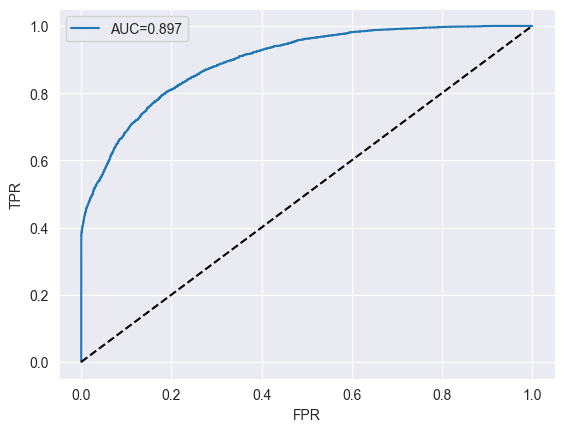

In [51]:
# ROC Curve Analysis
y_prob_test = model2.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [53]:
# Confusion matrix analysis
y_hat = (y_prob_test >= .5).astype(int)

# To select the best threshold for accuracy, it is compared against the default threshold (50%)
accuracy_50 = accuracy_score(y_true=y_test, y_pred=y_hat)

for u in np.arange(0,1,.001):
    y_hats = (y_prob_test >= u).astype(int)
    accuracy = accuracy_score(y_true=y_test, y_pred=y_hats)

    if accuracy_50 < accuracy:
        print(f"threshold: {u} --> accuracy: {accuracy_score(y_true=y_test, y_pred=y_hats):.4f}")

# A threshold of 0.467 is obtained as the optimal value to maximize accuracy
y_hat_final = (y_prob_test >= .467).astype(int)

threshold: 0.452 --> accuracy: 0.8193
threshold: 0.453 --> accuracy: 0.8193
threshold: 0.454 --> accuracy: 0.8194
threshold: 0.455 --> accuracy: 0.8196
threshold: 0.456 --> accuracy: 0.8197
threshold: 0.457 --> accuracy: 0.8196
threshold: 0.458 --> accuracy: 0.8196
threshold: 0.459 --> accuracy: 0.8200
threshold: 0.46 --> accuracy: 0.8203
threshold: 0.461 --> accuracy: 0.8204
threshold: 0.462 --> accuracy: 0.8203
threshold: 0.463 --> accuracy: 0.8203
threshold: 0.464 --> accuracy: 0.8204
threshold: 0.465 --> accuracy: 0.8203
threshold: 0.466 --> accuracy: 0.8206
threshold: 0.467 --> accuracy: 0.8208
threshold: 0.468 --> accuracy: 0.8206
threshold: 0.46900000000000003 --> accuracy: 0.8207
threshold: 0.47000000000000003 --> accuracy: 0.8208
threshold: 0.47100000000000003 --> accuracy: 0.8204
threshold: 0.47200000000000003 --> accuracy: 0.8203
threshold: 0.47300000000000003 --> accuracy: 0.8203
threshold: 0.47400000000000003 --> accuracy: 0.8201
threshold: 0.47500000000000003 --> accuracy

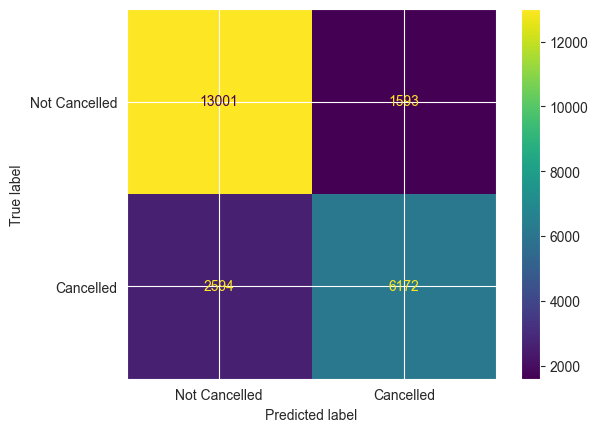

accuracy: 0.821
precision: 0.795
recall (sensitivity): 0.704
specificity: 0.891
f1-score: 0.747


In [54]:
# Model 2 performance evaluation
cm = confusion_matrix(y_true=y_test, y_pred=y_hat_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Cancelled', 'Cancelled'])
disp.plot()
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"accuracy: {accuracy_score(y_true=y_test, y_pred=y_hat_final):.3f}")
print(f"precision: {precision_score(y_true=y_test, y_pred=y_hat_final):.3f}")
print(f"recall (sensitivity): {recall_score(y_true=y_test, y_pred=y_hat_final):.3f}")
print(f"specificity: {tn/(tn+fp):.3f}")
print(f"f1-score: {f1_score(y_true=y_test, y_pred=y_hat_final):.3f}")

**Final conclussions of predictive model**

The model achieves an AUC of 0.897, indicating a strong discriminative capacity. The accuracy score shows that the model correctly classifies 82.1% of the predictions. Furthermore, the consistency between the cross-validation metrics on the training set and the test set metrics demonstrates the absence of overfitting. On the other hand, its main weakness is the recall score. Therefore, if the hotel's priority is to detect canceled reservations to implement overbooking strategies, the threshold should be lowered to minimize false negatives at the cost of a higher number of false positives.